In [1]:
"""
Pay Parity Across Multiple Demographics - MLPR Project
Authors: Kavyaa Agrawal, Sadhika Anand, Sahil Gada

REGRESSION VERSION — predicts actual WAGE income (WAGP in $).

Dataset: 5-state ACS master (CA, TX, FL, NY, IL)  — 1,238,284 raw rows, 12 columns:
  AGEP   Age
  COW    Class of worker
  MAR    Marital status
  SCHL   Education level
  SEX    Sex (1=Male, 2=Female)
  WAGP   Wage/salary income  <-- PRIMARY regression target
  WKHP   Hours worked per week
  INDP   Industry code
  OCCP   Occupation code
  PINCP  Total personal income (kept as a secondary reference column)
  RAC1P  Race
  STATE  State abbreviation (CA / TX / FL / NY / IL)

Why WAGP and not PINCP?
  WAGP = wages/salary only — directly measures labour market pay discrimination.
  PINCP = total income including investments, benefits, etc. — noisier for pay parity.

This script handles:
1. Loading the dataset
2. Cleaning (missing values, duplicates, age filter, WAGP > 0 filter)
3. Decoding numeric codes to human-readable labels
4. Outlier removal (IQR capping)
5. Low-earnings occupation filter
6. Feature engineering (log-transform target, normalise, target-encode, encode STATE)
7. 19 visualisations suited to a continuous wage target
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
uploaded = files.upload()

# ─────────────────────────────────────────────
# PLOT STYLE
# ─────────────────────────────────────────────
FEMALE_COLOR = "#5b7fa6"
MALE_COLOR   = "#c87941"
BG_COLOR     = "#f8f8f8"
plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor":   BG_COLOR,
    "axes.edgecolor":   "#cccccc",
    "axes.labelsize":   11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "font.family":      "sans-serif",
})
dollar_fmt = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")


# ══════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA
# ══════════════════════════════════════════════════════════════════
print("=" * 60)
print("SECTION 1: Loading data")
print("=" * 60)

df = pd.read_csv("pay_parity_5_states_master (1).csv")
print(f"Raw shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"\nState breakdown:\n{df['STATE'].value_counts().to_string()}")
print(f"\nMissing values per column:\n{df.isnull().sum().to_string()}")

# Track row counts at each step for a final summary
counts = {"0_raw": len(df)}



Saving pay_parity_5_states_master (1).csv to pay_parity_5_states_master (1).csv
SECTION 1: Loading data
Raw shape: 1,238,284 rows × 12 columns
Columns: ['AGEP', 'COW', 'MAR', 'SCHL', 'SEX', 'WAGP', 'WKHP', 'INDP', 'OCCP', 'PINCP', 'RAC1P', 'STATE']

State breakdown:
STATE
CA    393725
TX    292272
FL    213167
NY    210150
IL    128970

Missing values per column:
AGEP          0
COW      502225
MAR           0
SCHL      31174
SEX           0
WAGP     180156
WKHP     602276
INDP     502225
OCCP     502225
PINCP    180156
RAC1P         0
STATE         0


In [2]:

# ══════════════════════════════════════════════════════════════════
# SECTION 2 — INITIAL FILTERS (before decoding)
#
# 2a. Keep only working-age adults (18+).
#     Children and teenagers are not part of the labour market
#     and would only add noise to a wage model.
#
# 2b. Keep only rows where WAGP > 0.
#     WAGP = 0 means no wage income (retired, unemployed, students).
#     These records are not relevant to a pay-parity study.
#     We do NOT filter on PINCP here because PINCP includes investment
#     income and transfers — someone can have PINCP > 0 but WAGP = 0.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 2: Initial filters (age >= 18, WAGP > 0)")
print("=" * 60)

before = len(df)
df = df[df["AGEP"] >= 18].copy()
print(f"Removed {before - len(df):,} rows where age < 18")
counts["1_after_age_filter"] = len(df)

before = len(df)
df = df[df["WAGP"] > 0].copy()
print(f"Removed {before - len(df):,} rows where WAGP <= 0 (no wage income)")
counts["2_after_wagp_filter"] = len(df)

print(f"Remaining: {len(df):,} rows")


# ══════════════════════════════════════════════════════════════════
# SECTION 3 — DECODE NUMERIC CODES TO HUMAN-READABLE LABELS
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 3: Decoding ACS numeric codes -> labels")
print("=" * 60)

# -- SEX ----------------------------------------------------------
sex_map = {1: "Male", 2: "Female"}
df["SEX_LABEL"] = df["SEX"].map(sex_map)

# -- MARITAL STATUS (MAR) -----------------------------------------
mar_map = {1: "Married", 2: "Widowed", 3: "Divorced",
           4: "Separated", 5: "Never Married"}
df["MAR_LABEL"] = df["MAR"].map(mar_map)

# -- RACE (RAC1P) -------------------------------------------------
rac_map = {
    1: "White", 2: "Black", 3: "American Indian",
    4: "Alaska Native", 5: "American Indian/Alaska Native",
    6: "Asian", 7: "Native Hawaiian", 8: "Other",
    9: "Two or more races",
}
df["RAC1P_LABEL"] = df["RAC1P"].map(rac_map)

# -- CLASS OF WORKER (COW) ----------------------------------------
cow_map = {
    1: "Private for-profit", 2: "Private non-profit",
    3: "Local government",   4: "State government",
    5: "Federal government", 6: "Self-employed (inc)",
    7: "Self-employed (not inc)", 8: "Unpaid family",
    9: "Unemployed",
}
df["COW_LABEL"] = df["COW"].map(cow_map)

# -- EDUCATION (SCHL) ---------------------------------------------
schl_map = {
    1: "No schooling", 2: "Nursery", 3: "Kindergarten",
    4: "Grade 1",  5: "Grade 2",  6: "Grade 3",  7: "Grade 4",
    8: "Grade 5",  9: "Grade 6", 10: "Grade 7", 11: "Grade 8",
    12: "Grade 9", 13: "Grade 10", 14: "Grade 11", 15: "Grade 12",
    16: "High School", 17: "GED",
    18: "Some College <1yr", 19: "Some College >1yr",
    20: "Associate", 21: "Bachelor", 22: "Master",
    23: "Professional", 24: "Doctorate",
}
df["SCHL_LABEL"] = df["SCHL"].map(schl_map)

print("Label columns added: SEX_LABEL, MAR_LABEL, RAC1P_LABEL, COW_LABEL, SCHL_LABEL")


# ══════════════════════════════════════════════════════════════════
# SECTION 4 — CLEANING: missing values & duplicates
#
# After filtering to WAGP > 0 and age >= 18, we drop any remaining
# rows that are missing values in the key feature columns.
# COW, OCCP, WKHP, SCHL can still have NaNs (e.g. self-employed
# people sometimes skip occupation fields).
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 4: Cleaning — missing values & duplicates")
print("=" * 60)

before = len(df)
key_cols = ["SEX", "SCHL", "MAR", "RAC1P", "COW", "OCCP", "AGEP", "WKHP", "WAGP"]
df.dropna(subset=key_cols, inplace=True)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Removed {before - after:,} rows (missing values / duplicates)")
print(f"Clean dataset: {after:,} rows")
counts["3_after_cleaning"] = len(df)


# ══════════════════════════════════════════════════════════════════
# SECTION 5 — OUTLIER REMOVAL (IQR capping)
#
# Wages have an extreme right tail (a few people earn millions).
# IQR capping clips these to the 1.5×IQR upper fence rather than
# deleting the row — keeps data volume while reducing distortion.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 5: Outlier removal (IQR capping on continuous cols)")
print("=" * 60)

def iqr_cap(series, name=""):
    """Clip values outside 1.5 × IQR to the fence values."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    capped = series.clip(lower, upper)
    changed = (series != capped).sum()
    print(f"  {name}: capped {changed:,} values  [{lower:.1f} - {upper:.1f}]")
    return capped

df["AGEP"] = iqr_cap(df["AGEP"], "AGEP  (age)")
df["WKHP"] = iqr_cap(df["WKHP"], "WKHP  (hrs/week)")
# Cap the wage — reduces extreme-earner influence without losing rows
df["WAGP"] = iqr_cap(df["WAGP"], "WAGP  (wage $)")
counts["4_after_iqr_cap"] = len(df)   # same count, no rows removed

print(f"\nWAGP after capping:\n{df['WAGP'].describe().apply(lambda x: f'${x:,.0f}')}")


# ══════════════════════════════════════════════════════════════════
# SECTION 6 — REMOVE LOW-EARNINGS OCCUPATIONS
#
# Occupations whose median wage < $15,000 (roughly half-time at
# federal minimum wage) offer almost no variance for pay-parity
# analysis. Dropping them sharpens the model signal.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 6: Removing very-low-earnings occupations (median WAGP < $15k)")
print("=" * 60)

occ_median = df.groupby("OCCP")["WAGP"].median()
valid_occp  = occ_median[occ_median >= 15_000].index
before_occ  = len(df)
df = df[df["OCCP"].isin(valid_occp)].copy()
print(f"Removed {before_occ - len(df):,} rows from very-low-earnings occupations")
print(f"Dataset after occupation filter: {len(df):,} rows")
counts["5_after_occ_filter"] = len(df)



SECTION 2: Initial filters (age >= 18, WAGP > 0)
Removed 224,388 rows where age < 18
Removed 424,383 rows where WAGP <= 0 (no wage income)
Remaining: 589,513 rows

SECTION 3: Decoding ACS numeric codes -> labels
Label columns added: SEX_LABEL, MAR_LABEL, RAC1P_LABEL, COW_LABEL, SCHL_LABEL

SECTION 4: Cleaning — missing values & duplicates
Removed 12,415 rows (missing values / duplicates)
Clean dataset: 577,098 rows

SECTION 5: Outlier removal (IQR capping on continuous cols)
  AGEP  (age): capped 129 values  [-6.5 - 93.5]
  WKHP  (hrs/week): capped 178,628 values  [27.5 - 47.5]
  WAGP  (wage $): capped 37,440 values  [-72500.0 - 187500.0]

WAGP after capping:
count    $577,098
mean      $63,932
std       $51,872
min            $4
25%       $25,000
50%       $50,000
75%       $90,000
max      $187,500
Name: WAGP, dtype: object

SECTION 6: Removing very-low-earnings occupations (median WAGP < $15k)
Removed 9,177 rows from very-low-earnings occupations
Dataset after occupation filter: 56

In [3]:
# ══════════════════════════════════════════════════════════════════
# SECTION 7 — FEATURE ENGINEERING
#
# 7a. Log-transform WAGP -> WAGP_LOG  (regression target)
#     Wages are right-skewed; log makes the distribution near-normal
#     which is much better for XGBoost regression.
#     To recover dollar predictions: np.expm1(model.predict(X))
#
# 7b. MinMax-normalise AGEP and WKHP (0-1).
#
# 7c. Smoothed mean-target encoding for high-cardinality categoricals.
#     Each category level is replaced by its smoothed mean log-wage,
#     shrunk toward the global mean for rare levels.
#
# 7d. One-hot encode STATE (5 states -> 5 binary columns).
#     State captures regional cost-of-living differences which are
#     a real confound in cross-state wage comparisons.
#
# 7e. Binary-encode SEX (Male=1, Female=0).
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 7: Feature engineering")
print("=" * 60)

# -- 7a. Log-transform the wage target ----------------------------
df["WAGP_LOG"] = np.log1p(df["WAGP"])
print("Created WAGP_LOG = log1p(WAGP)  <-- regression target")
print(f"  WAGP_LOG range: {df['WAGP_LOG'].min():.2f} - {df['WAGP_LOG'].max():.2f}")

# -- 7b. MinMax normalisation on continuous features --------------
scaler   = MinMaxScaler()
num_cols = ["AGEP", "WKHP"]
df[num_cols] = scaler.fit_transform(df[num_cols])
print(f"Normalised (MinMax -> 0-1): {num_cols}")

# -- 7c. Smoothed mean-target encoding ----------------------------
def target_encode(df, col, target="WAGP_LOG", smoothing=10):
    """
    Smoothed mean-target encoding:
        encoded = (n_i * mean_i + k * global_mean) / (n_i + k)
    k = smoothing factor; higher = more regularisation for rare levels.
    """
    global_mean = df[target].mean()
    stats  = df.groupby(col)[target].agg(["mean", "count"])
    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / \
             (stats["count"] + smoothing)
    return df[col].map(smooth)

# -- 7d. One-hot encode STATE ------------------------------------
# This gives the model a way to capture state-level wage differences
# (e.g. CA and NY generally pay more than FL for the same job).
state_dummies = pd.get_dummies(df["STATE"], prefix="STATE", drop_first=False)
df = pd.concat([df, state_dummies], axis=1)
state_cols = list(state_dummies.columns)
print(f"One-hot encoded STATE -> {state_cols}")

# -- 7e. Binary-encode SEX ----------------------------------------
df["SEX_BIN"] = (df["SEX"] == 1).astype(int)   # 1 = Male, 0 = Female
print("Binary-encoded: SEX -> SEX_BIN (1 = Male, 0 = Female)")

# -- 7f. Assemble the model-ready dataframe -----------------------
model_cols = (
    ["AGEP", "COW", "SCHL", "MAR",
     "OCCP", "WKHP", "SEX_BIN", "RAC1P"]
    + state_cols
    + ["WAGP_LOG"]   # <-- regression target, always last
)
df_model = df[model_cols].copy()
print(f"\nModel-ready dataframe shape: {df_model.shape}")
print(df_model.head())

# Save
df.to_csv("pay_parity_preprocessed.csv", index=False)
df_model.to_csv("pay_parity_model_ready.csv", index=False)
print("\nSaved: pay_parity_preprocessed.csv  (full, with labels)")
print("Saved: pay_parity_model_ready.csv   (numeric, model-ready)")
print("       -> Target = WAGP_LOG  |  use np.expm1(pred) to get $ back")


# ══════════════════════════════════════════════════════════════════
# SECTION 8 — ROW-COUNT SUMMARY
# Print a clear table of how many rows were removed at each step.
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 8: Data point count summary")
print("=" * 60)

counts["6_final"] = len(df)
labels = {
    "0_raw":               "Raw dataset",
    "1_after_age_filter":  "After removing age < 18",
    "2_after_wagp_filter": "After removing WAGP <= 0",
    "3_after_cleaning":    "After missing values / duplicates",
    "4_after_iqr_cap":     "After IQR capping (no rows removed)",
    "5_after_occ_filter":  "After low-earnings occupation filter",
    "6_final":             "FINAL dataset",
}
prev = None
for key, label in labels.items():
    n = counts[key]
    if prev is not None:
        removed = prev - n
        pct     = removed / counts["0_raw"] * 100
        print(f"  {label:<45} {n:>9,}  (removed {removed:>7,} = {pct:.1f}% of raw)")
    else:
        print(f"  {label:<45} {n:>9,}")
    prev = n

total_removed = counts["0_raw"] - counts["6_final"]
print(f"\n  Total rows removed: {total_removed:,}  "
      f"({total_removed/counts['0_raw']*100:.1f}% of raw)")
print(f"  Final dataset:      {counts['6_final']:,} rows")




SECTION 7: Feature engineering
Created WAGP_LOG = log1p(WAGP)  <-- regression target
  WAGP_LOG range: 1.61 - 12.14
Normalised (MinMax -> 0-1): ['AGEP', 'WKHP']
One-hot encoded STATE -> ['STATE_CA', 'STATE_FL', 'STATE_IL', 'STATE_NY', 'STATE_TX']
Binary-encoded: SEX -> SEX_BIN (1 = Male, 0 = Female)

Model-ready dataframe shape: (567921, 14)
        AGEP  COW  SCHL  MAR    OCCP   WKHP  SEX_BIN  RAC1P  STATE_CA  \
0   0.357616  2.0   7.0    1  9150.0  1.000        1      9      True   
2   0.039735  5.0  20.0    5   725.0  0.000        0      8      True   
4   0.013245  1.0  18.0    5  1970.0  0.000        0      6      True   
13  0.556291  2.0  24.0    1   725.0  0.875        0      1      True   
18  0.013245  4.0  19.0    5  4130.0  0.000        1      1      True   

    STATE_FL  STATE_IL  STATE_NY  STATE_TX   WAGP_LOG  
0      False     False     False     False  11.156265  
2      False     False     False     False   8.006701  
4      False     False     False     False   9.4


SECTION 9: Generating visualizations


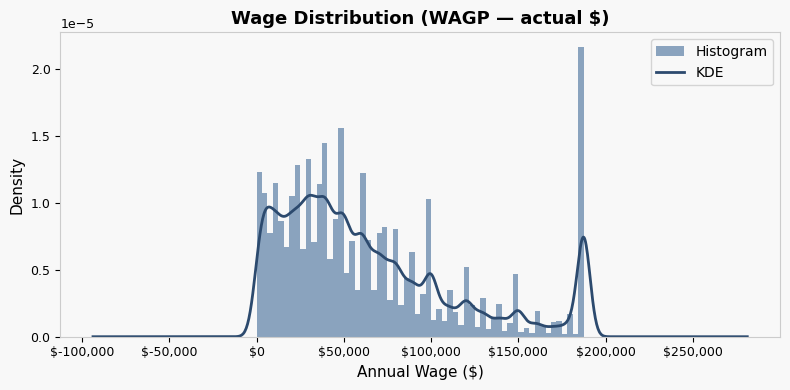

  Saved -> plot1_wage_distribution.png


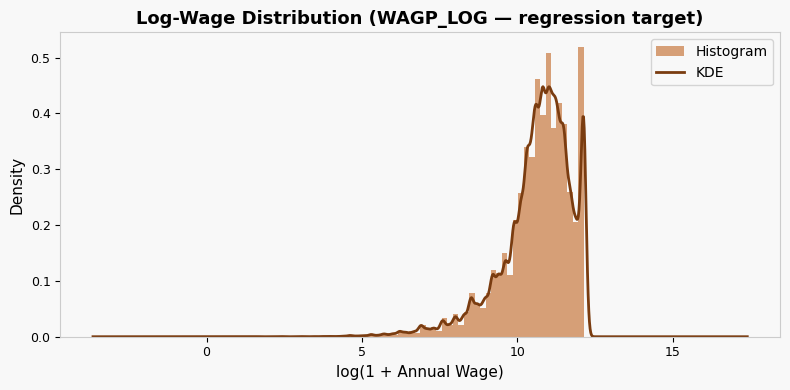

  Saved -> plot2_log_wage_distribution.png


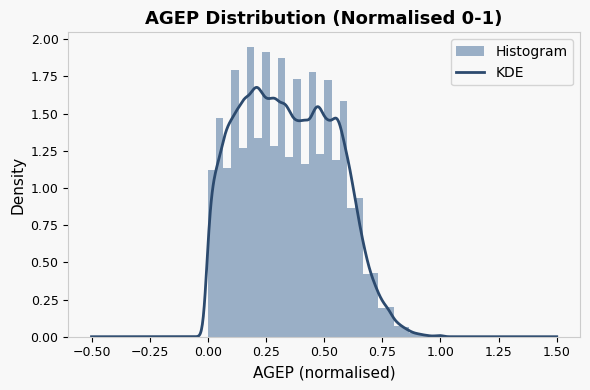

  Saved -> plot3_age_distribution.png


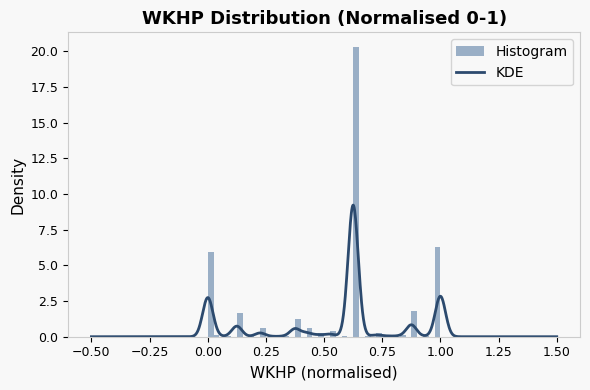

  Saved -> plot4_wkhp_distribution.png


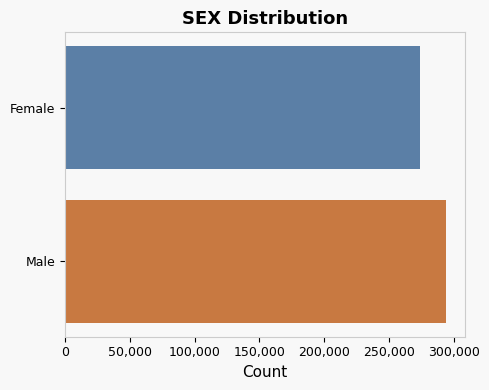

  Saved -> plot5_sex_distribution.png


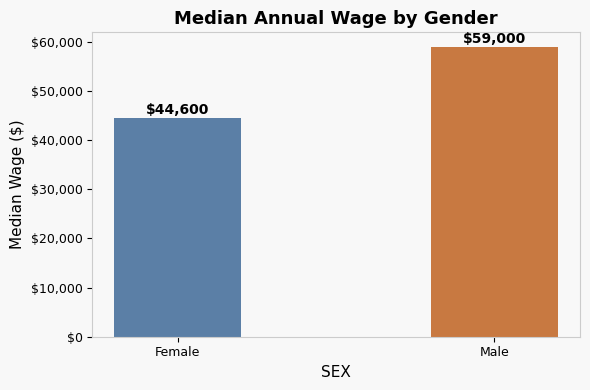

  Saved -> plot6_median_wage_by_gender.png


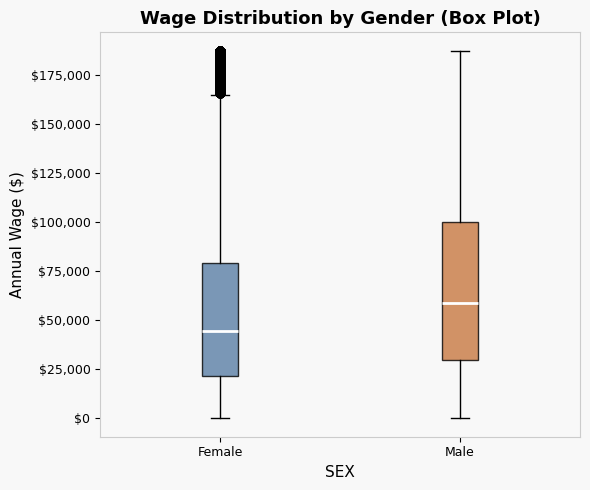

  Saved -> plot7_wage_boxplot_by_gender.png


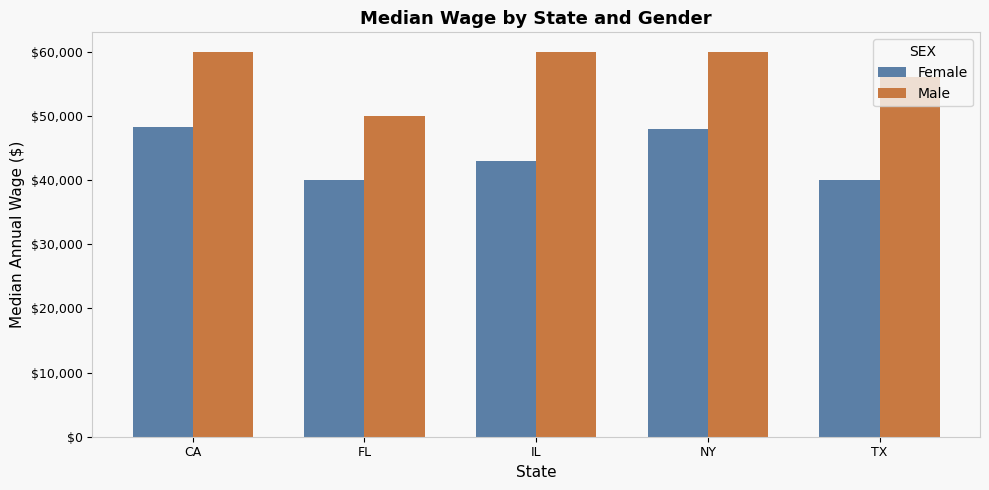

  Saved -> plot8_median_wage_by_state_gender.png


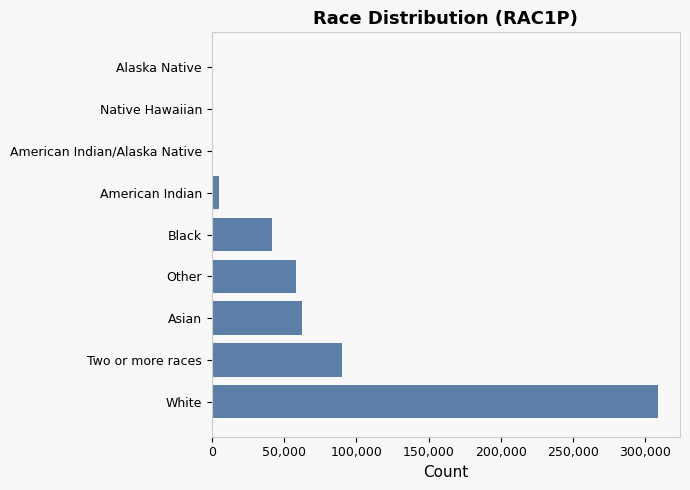

  Saved -> plot9_race_distribution.png


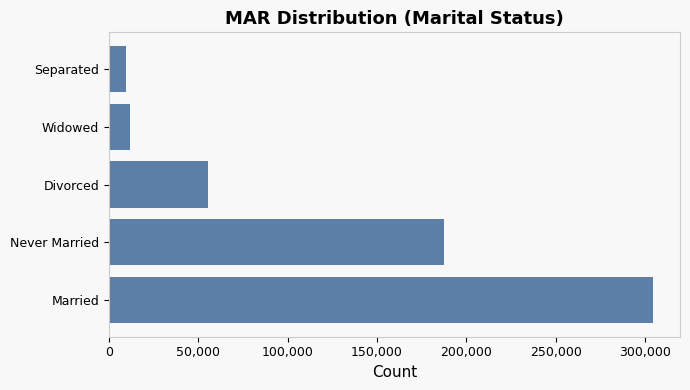

  Saved -> plot10_mar_distribution.png


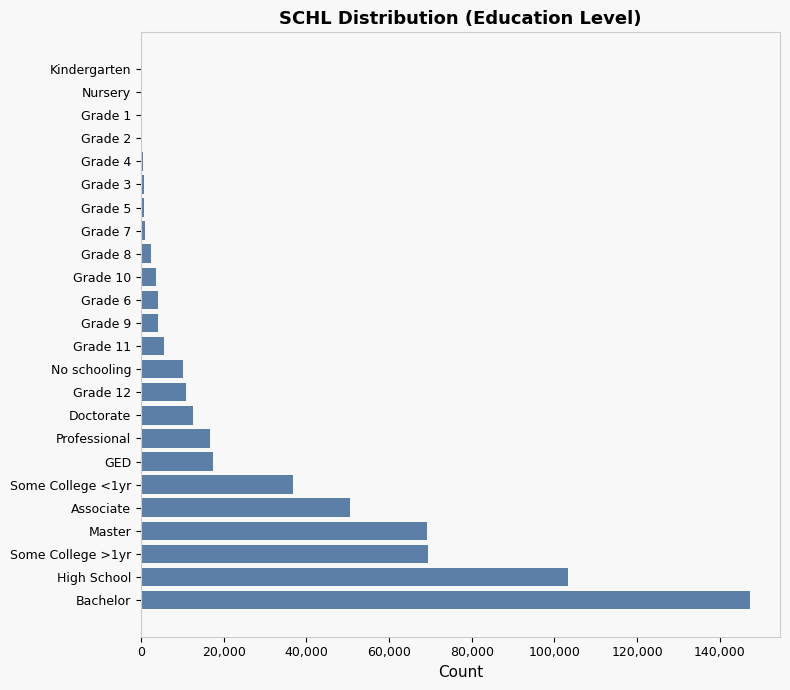

  Saved -> plot11_schl_distribution.png


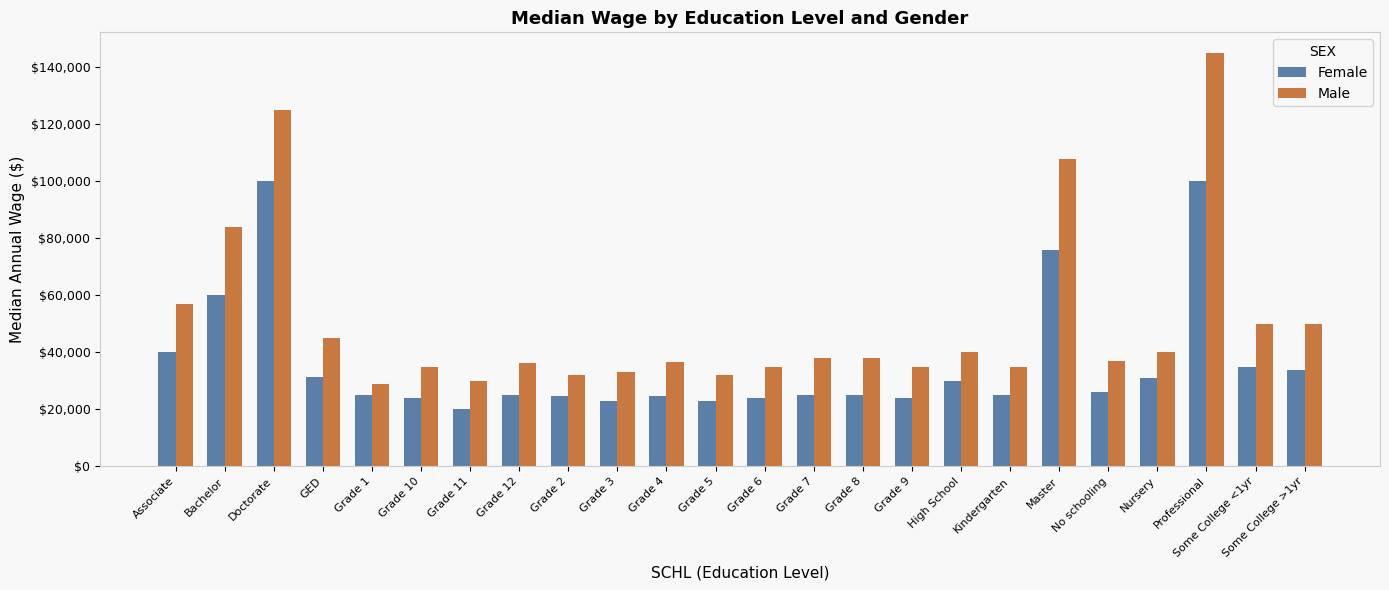

  Saved -> plot12_median_wage_by_education_gender.png


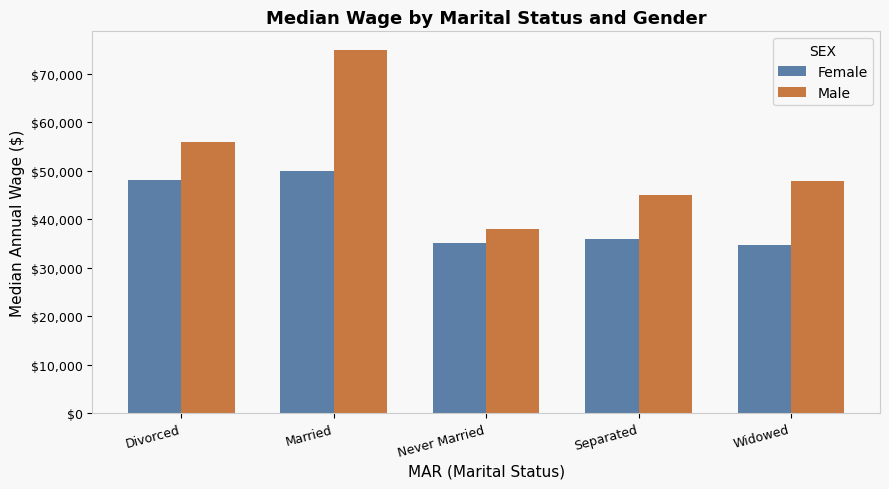

  Saved -> plot13_median_wage_by_marital_gender.png


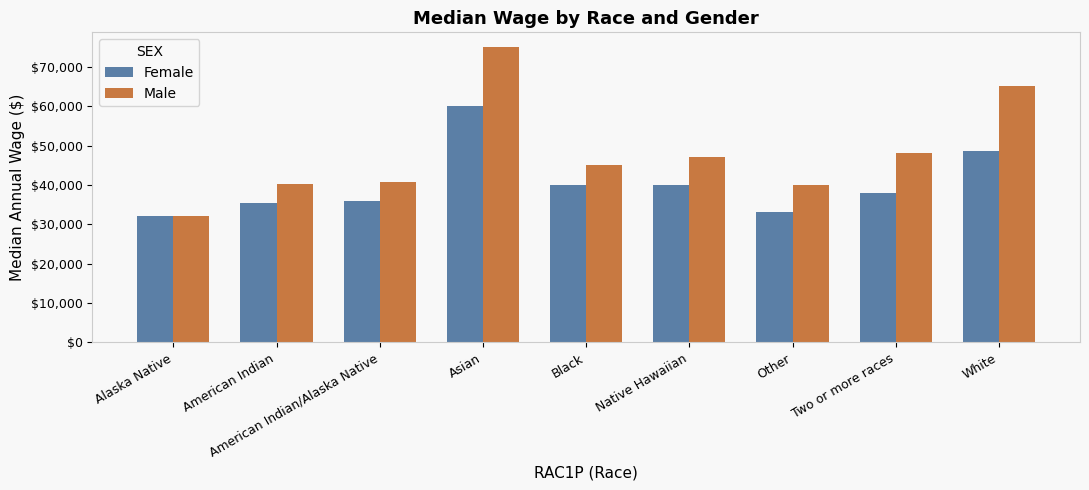

  Saved -> plot14_median_wage_by_race_gender.png


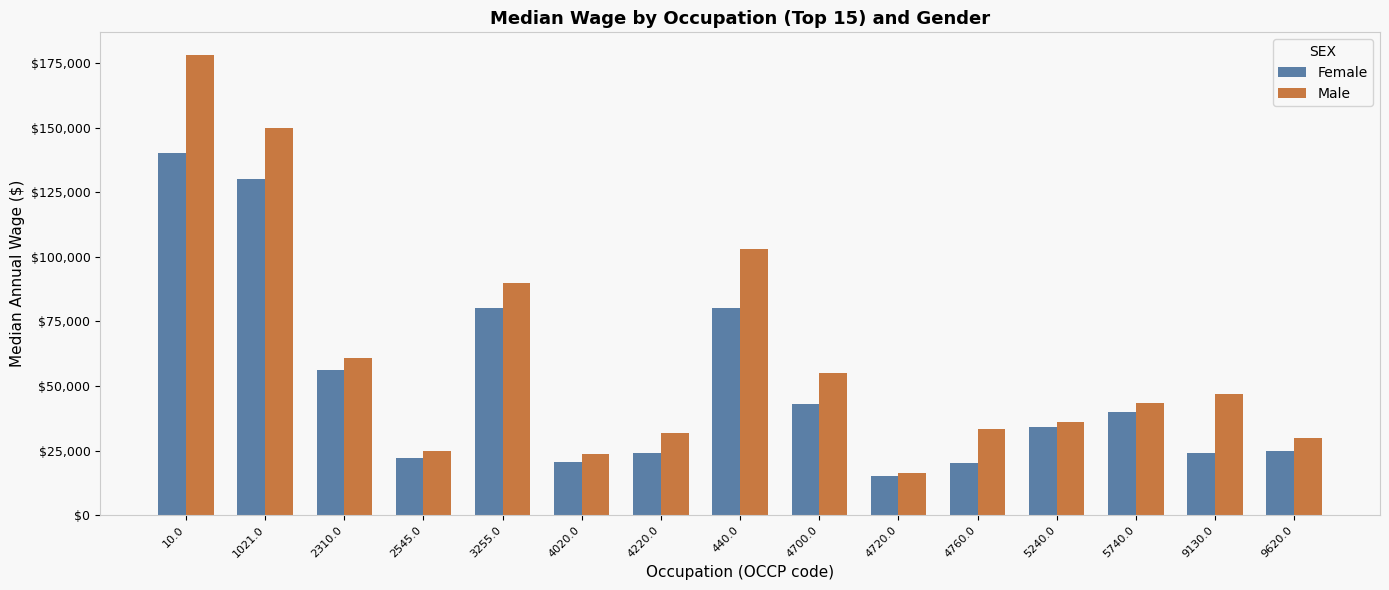

  Saved -> plot15_median_wage_by_occupation_gender.png


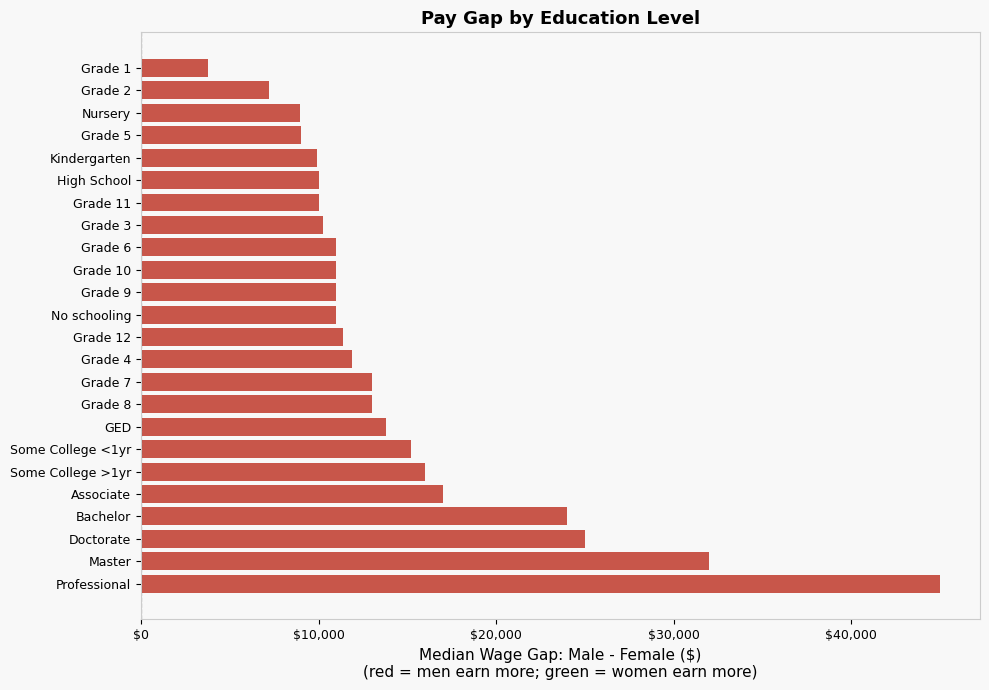

  Saved -> plot16_gap_by_education.png


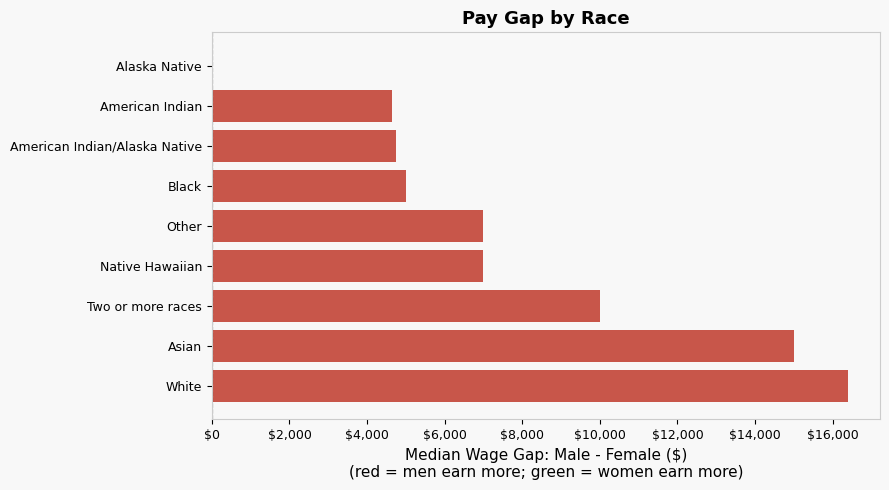

  Saved -> plot17_gap_by_race.png


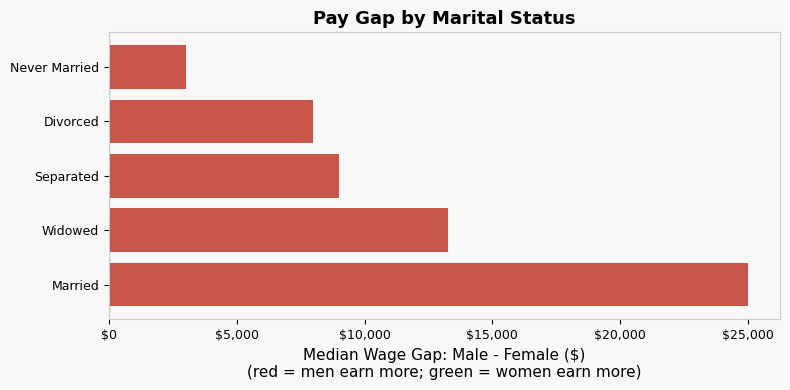

  Saved -> plot18_gap_by_marital_status.png


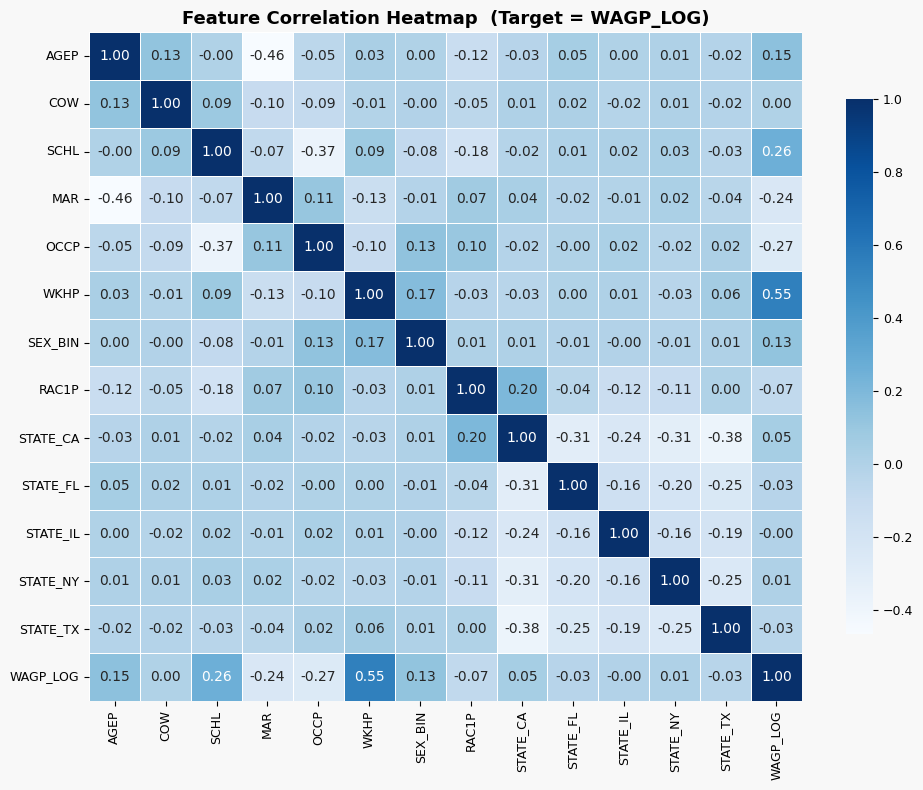

  Saved -> plot19_correlation_heatmap.png

  Median male wage:   $59,000
  Median female wage: $44,600
  Raw gap:            $14,400
  Women earn 0.76 cents per $1 earned by men


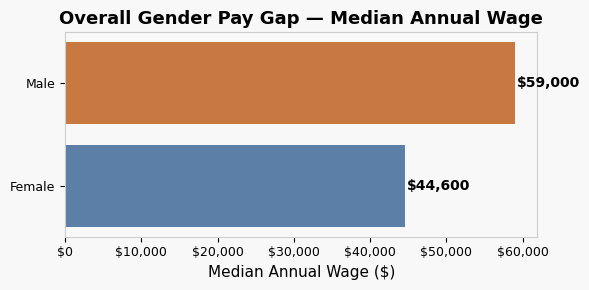

  Saved -> plot20_overall_gender_pay_gap.png

ALL DONE!

Files saved:
  pay_parity_preprocessed.csv   -- full cleaned data with labels
  pay_parity_model_ready.csv    -- numeric-only, ready for XGBoost
                                    TARGET = WAGP_LOG
                                    use np.expm1(pred) to get $ back

Plots saved (20 total):
  plot1  -- Wage distribution (actual $)
  plot2  -- Log-wage distribution (regression target shape check)
  plot3  -- Age distribution (normalised)
  plot4  -- Hours/week distribution (normalised)
  plot5  -- Sex distribution
  plot6  -- Median wage by gender (bar)
  plot7  -- Wage distribution by gender (box plot)
  plot8  -- Median wage by STATE and gender  [new -- 5-state dataset]
  plot9  -- Race distribution
  plot10 -- Marital status distribution
  plot11 -- Education distribution
  plot12 -- Median wage by education & gender
  plot13 -- Median wage by marital status & gender
  plot14 -- Median wage by race & gender (intersectional)
  

In [4]:

# ══════════════════════════════════════════════════════════════════
# SECTION 9 — VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("SECTION 9: Generating visualizations")
print("=" * 60)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {name}.png")

width = 0.35


# ── PLOT 1: Wage Distribution (actual $) ─────────────────────────
# Histogram + KDE of actual wages after capping.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["WAGP"], bins=60, color=FEMALE_COLOR, alpha=0.7,
        density=True, label="Histogram")
df["WAGP"].plot.kde(ax=ax, color="#2c4a6e", linewidth=2, label="KDE")
ax.set_title("Wage Distribution (WAGP — actual $)")
ax.set_xlabel("Annual Wage ($)")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(dollar_fmt)
ax.legend()
save_fig("plot1_wage_distribution")


# ── PLOT 2: Log-Wage Distribution (regression target shape) ──────
# Confirms the log-transform produces a near-normal distribution.
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["WAGP_LOG"], bins=60, color=MALE_COLOR, alpha=0.7,
        density=True, label="Histogram")
df["WAGP_LOG"].plot.kde(ax=ax, color="#7a3c10", linewidth=2, label="KDE")
ax.set_title("Log-Wage Distribution (WAGP_LOG — regression target)")
ax.set_xlabel("log(1 + Annual Wage)")
ax.set_ylabel("Density")
ax.legend()
save_fig("plot2_log_wage_distribution")


# ── PLOT 3: Age Distribution (normalised) ────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["AGEP"], bins=30, color=FEMALE_COLOR, alpha=0.6,
        density=True, label="Histogram")
df["AGEP"].plot.kde(ax=ax, color="#2c4a6e", linewidth=2, label="KDE")
ax.set_title("AGEP Distribution (Normalised 0-1)")
ax.set_xlabel("AGEP (normalised)")
ax.set_ylabel("Density")
ax.legend()
save_fig("plot3_age_distribution")


# ── PLOT 4: Hours-per-week Distribution (normalised) ─────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df["WKHP"], bins=40, color=FEMALE_COLOR, alpha=0.6,
        density=True, label="Histogram")
df["WKHP"].plot.kde(ax=ax, color="#2c4a6e", linewidth=2, label="KDE")
ax.set_title("WKHP Distribution (Normalised 0-1)")
ax.set_xlabel("WKHP (normalised)")
ax.set_ylabel("Density")
ax.legend()
save_fig("plot4_wkhp_distribution")


# ── PLOT 5: Sex Distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sex_counts = df["SEX_LABEL"].value_counts()
ax.barh(sex_counts.index, sex_counts.values,
        color=[FEMALE_COLOR if s == "Female" else MALE_COLOR
               for s in sex_counts.index])
ax.set_title("SEX Distribution")
ax.set_xlabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
save_fig("plot5_sex_distribution")


# ── PLOT 6: Median Wage by Gender (bar) ──────────────────────────
# Primary pay-gap chart — actual median dollar wages side by side.
fig, ax = plt.subplots(figsize=(6, 4))
med_sex = df.groupby("SEX_LABEL")["WAGP"].median()
bars = ax.bar(med_sex.index, med_sex.values,
              color=[FEMALE_COLOR if s == "Female" else MALE_COLOR
                     for s in med_sex.index],
              width=0.4)
ax.set_title("Median Annual Wage by Gender")
ax.set_xlabel("SEX")
ax.set_ylabel("Median Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
for bar, val in zip(bars, med_sex.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 200,
            f"${val:,.0f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
save_fig("plot6_median_wage_by_gender")


# ── PLOT 7: Wage Distribution by Gender (box plot) ───────────────
# Shows the full spread — quartiles and outliers — not just median.
fig, ax = plt.subplots(figsize=(6, 5))
groups = [df.loc[df["SEX_LABEL"] == g, "WAGP"].values
          for g in ["Female", "Male"]]
bp = ax.boxplot(groups, labels=["Female", "Male"],
                patch_artist=True,
                medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], [FEMALE_COLOR, MALE_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title("Wage Distribution by Gender (Box Plot)")
ax.set_xlabel("SEX")
ax.set_ylabel("Annual Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
save_fig("plot7_wage_boxplot_by_gender")


# ── PLOT 8: Median Wage by State & Gender ────────────────────────
# New chart enabled by the multi-state dataset.
# Shows state-level wage gaps side by side.
fig, ax = plt.subplots(figsize=(10, 5))
med_state = (df.groupby(["STATE", "SEX_LABEL"])["WAGP"]
               .median().reset_index()
               .rename(columns={"WAGP": "median_wage"}))
pivot_state = med_state.pivot(index="STATE", columns="SEX_LABEL",
                               values="median_wage")
x = np.arange(len(pivot_state))
ax.bar(x - width/2, pivot_state.get("Female", 0), width,
       label="Female", color=FEMALE_COLOR)
ax.bar(x + width/2, pivot_state.get("Male",   0), width,
       label="Male",   color=MALE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(pivot_state.index)
ax.set_title("Median Wage by State and Gender")
ax.set_xlabel("State")
ax.set_ylabel("Median Annual Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(title="SEX")
save_fig("plot8_median_wage_by_state_gender")


# ── PLOT 9: Race Distribution ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
race_counts = df["RAC1P_LABEL"].value_counts()
ax.barh(race_counts.index, race_counts.values, color=FEMALE_COLOR)
ax.set_title("Race Distribution (RAC1P)")
ax.set_xlabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
save_fig("plot9_race_distribution")


# ── PLOT 10: Marital Status Distribution ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
mar_counts = df["MAR_LABEL"].value_counts()
ax.barh(mar_counts.index, mar_counts.values, color=FEMALE_COLOR)
ax.set_title("MAR Distribution (Marital Status)")
ax.set_xlabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
save_fig("plot10_mar_distribution")


# ── PLOT 11: Education Distribution (SCHL) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
schl_counts = df["SCHL_LABEL"].value_counts()
ax.barh(schl_counts.index, schl_counts.values, color=FEMALE_COLOR)
ax.set_title("SCHL Distribution (Education Level)")
ax.set_xlabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
save_fig("plot11_schl_distribution")


# ── PLOT 12: Median Wage by Education Level & Gender ─────────────
fig, ax = plt.subplots(figsize=(14, 6))
med_schl = (df.groupby(["SCHL_LABEL", "SEX_LABEL"])["WAGP"]
              .median().reset_index()
              .rename(columns={"WAGP": "median_wage"}))
pivot_schl = (med_schl.pivot(index="SCHL_LABEL", columns="SEX_LABEL",
                               values="median_wage").sort_index())
x = np.arange(len(pivot_schl))
ax.bar(x - width/2, pivot_schl.get("Female", 0), width,
       label="Female", color=FEMALE_COLOR)
ax.bar(x + width/2, pivot_schl.get("Male",   0), width,
       label="Male",   color=MALE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(pivot_schl.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Median Wage by Education Level and Gender")
ax.set_xlabel("SCHL (Education Level)")
ax.set_ylabel("Median Annual Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(title="SEX")
save_fig("plot12_median_wage_by_education_gender")


# ── PLOT 13: Median Wage by Marital Status & Gender ──────────────
fig, ax = plt.subplots(figsize=(9, 5))
med_mar = (df.groupby(["MAR_LABEL", "SEX_LABEL"])["WAGP"]
             .median().reset_index()
             .rename(columns={"WAGP": "median_wage"}))
pivot_mar = med_mar.pivot(index="MAR_LABEL", columns="SEX_LABEL",
                           values="median_wage")
x = np.arange(len(pivot_mar))
ax.bar(x - width/2, pivot_mar.get("Female", 0), width,
       label="Female", color=FEMALE_COLOR)
ax.bar(x + width/2, pivot_mar.get("Male",   0), width,
       label="Male",   color=MALE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(pivot_mar.index, rotation=15, ha="right")
ax.set_title("Median Wage by Marital Status and Gender")
ax.set_xlabel("MAR (Marital Status)")
ax.set_ylabel("Median Annual Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(title="SEX")
save_fig("plot13_median_wage_by_marital_gender")


# ── PLOT 14: Median Wage by Race & Gender (intersectional) ───────
fig, ax = plt.subplots(figsize=(11, 5))
med_race = (df.groupby(["RAC1P_LABEL", "SEX_LABEL"])["WAGP"]
              .median().reset_index()
              .rename(columns={"WAGP": "median_wage"}))
pivot_race = med_race.pivot(index="RAC1P_LABEL", columns="SEX_LABEL",
                             values="median_wage")
x = np.arange(len(pivot_race))
ax.bar(x - width/2, pivot_race.get("Female", 0), width,
       label="Female", color=FEMALE_COLOR)
ax.bar(x + width/2, pivot_race.get("Male",   0), width,
       label="Male",   color=MALE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(pivot_race.index, rotation=30, ha="right")
ax.set_title("Median Wage by Race and Gender")
ax.set_xlabel("RAC1P (Race)")
ax.set_ylabel("Median Annual Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(title="SEX")
save_fig("plot14_median_wage_by_race_gender")


# ── PLOT 15: Median Wage by Occupation (Top 15) & Gender ─────────
top_occp        = df["OCCP"].value_counts().nlargest(15).index
df_occp         = df[df["OCCP"].isin(top_occp)].copy()
df_occp["OCCP_STR"] = df_occp["OCCP"].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
med_occp = (df_occp.groupby(["OCCP_STR", "SEX_LABEL"])["WAGP"]
                   .median().reset_index()
                   .rename(columns={"WAGP": "median_wage"}))
pivot_occp = med_occp.pivot(index="OCCP_STR", columns="SEX_LABEL",
                             values="median_wage")
x = np.arange(len(pivot_occp))
ax.bar(x - width/2, pivot_occp.get("Female", 0), width,
       label="Female", color=FEMALE_COLOR)
ax.bar(x + width/2, pivot_occp.get("Male",   0), width,
       label="Male",   color=MALE_COLOR)
ax.set_xticks(x)
ax.set_xticklabels(pivot_occp.index, rotation=45, ha="right", fontsize=8)
ax.set_title("Median Wage by Occupation (Top 15) and Gender")
ax.set_xlabel("Occupation (OCCP code)")
ax.set_ylabel("Median Annual Wage ($)")
ax.yaxis.set_major_formatter(dollar_fmt)
ax.legend(title="SEX")
save_fig("plot15_median_wage_by_occupation_gender")


# ── PLOT 16-18: Pay Gap charts (dollar difference per group) ─────
# Gap = median(male wage) - median(female wage) within each category.
# Red = men earn more; green = women earn more.
def gap_chart(df, label_col, title, figsize=(10, 5), fname="gap"):
    med = df.groupby([label_col, "SEX_LABEL"])["WAGP"].median().unstack("SEX_LABEL")
    med["Gap ($)"] = med.get("Male", 0) - med.get("Female", 0)
    med = med.sort_values("Gap ($)", ascending=False)
    colors = ["#c0392b" if v > 0 else "#27ae60" for v in med["Gap ($)"]]
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(med.index, med["Gap ($)"], color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Median Wage Gap: Male - Female ($)\n"
                  "(red = men earn more; green = women earn more)")
    ax.xaxis.set_major_formatter(dollar_fmt)
    save_fig(fname)

gap_chart(df, "SCHL_LABEL",  "Pay Gap by Education Level",
          figsize=(10, 7), fname="plot16_gap_by_education")
gap_chart(df, "RAC1P_LABEL", "Pay Gap by Race",
          figsize=(9, 5),  fname="plot17_gap_by_race")
gap_chart(df, "MAR_LABEL",   "Pay Gap by Marital Status",
          figsize=(8, 4),  fname="plot18_gap_by_marital_status")


# ── PLOT 19: Correlation heatmap ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_model.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap  (Target = WAGP_LOG)")
save_fig("plot19_correlation_heatmap")


# ── PLOT 20: Overall gender pay gap headline ──────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
overall = df.groupby("SEX_LABEL")["WAGP"].median()
bars = ax.barh(overall.index, overall.values,
               color=[FEMALE_COLOR if s == "Female" else MALE_COLOR
                      for s in overall.index])
ax.set_xlabel("Median Annual Wage ($)")
ax.set_title("Overall Gender Pay Gap — Median Annual Wage")
ax.xaxis.set_major_formatter(dollar_fmt)
for bar, val in zip(bars, overall.values):
    ax.text(val + 200, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=10, fontweight="bold")

male_med   = overall.get("Male",   0)
female_med = overall.get("Female", 0)
gap        = male_med - female_med
ratio      = female_med / male_med if male_med else 0
print(f"\n  Median male wage:   ${male_med:,.0f}")
print(f"  Median female wage: ${female_med:,.0f}")
print(f"  Raw gap:            ${gap:,.0f}")
print(f"  Women earn {ratio:.2f} cents per $1 earned by men")
save_fig("plot20_overall_gender_pay_gap")


print("\n" + "=" * 60)
print("ALL DONE!")
print("=" * 60)
print("""
Files saved:
  pay_parity_preprocessed.csv   -- full cleaned data with labels
  pay_parity_model_ready.csv    -- numeric-only, ready for XGBoost
                                    TARGET = WAGP_LOG
                                    use np.expm1(pred) to get $ back

Plots saved (20 total):
  plot1  -- Wage distribution (actual $)
  plot2  -- Log-wage distribution (regression target shape check)
  plot3  -- Age distribution (normalised)
  plot4  -- Hours/week distribution (normalised)
  plot5  -- Sex distribution
  plot6  -- Median wage by gender (bar)
  plot7  -- Wage distribution by gender (box plot)
  plot8  -- Median wage by STATE and gender  [new -- 5-state dataset]
  plot9  -- Race distribution
  plot10 -- Marital status distribution
  plot11 -- Education distribution
  plot12 -- Median wage by education & gender
  plot13 -- Median wage by marital status & gender
  plot14 -- Median wage by race & gender (intersectional)
  plot15 -- Median wage by occupation & gender (top 15)
  plot16 -- Pay gap ($ diff) by education level
  plot17 -- Pay gap ($ diff) by race
  plot18 -- Pay gap ($ diff) by marital status
  plot19 -- Feature correlation heatmap
  plot20 -- Overall gender pay gap headline
""")

In [5]:
from sklearn.model_selection import train_test_split
df = df.drop(columns=['PINCP'])
df_model = df.copy()
train_df, temp_df = train_test_split(df_model, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 567921 entries, 0 to 1238283
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   AGEP         567921 non-null  float64
 1   COW          567921 non-null  float64
 2   MAR          567921 non-null  int64  
 3   SCHL         567921 non-null  float64
 4   SEX          567921 non-null  int64  
 5   WAGP         567921 non-null  float64
 6   WKHP         567921 non-null  float64
 7   INDP         567921 non-null  float64
 8   OCCP         567921 non-null  float64
 9   RAC1P        567921 non-null  int64  
 10  STATE        567921 non-null  object 
 11  SEX_LABEL    567921 non-null  object 
 12  MAR_LABEL    567921 non-null  object 
 13  RAC1P_LABEL  567921 non-null  object 
 14  COW_LABEL    567921 non-null  object 
 15  SCHL_LABEL   567921 non-null  object 
 16  WAGP_LOG     567921 non-null  float64
 17  STATE_CA     567921 non-null  bool   
 18  STATE_FL     567921 non-null

In [7]:
def fit_target_encoding(train_df, col, target="WAGP_LOG", smoothing=10):
    global_mean = train_df[target].mean()

    stats = train_df.groupby(col)[target].agg(["mean", "count"])

    smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / \
             (stats["count"] + smoothing)

    return smooth, global_mean

In [8]:
def apply_encoding(df, col, mapping, global_mean):
    return df[col].map(mapping).fillna(global_mean)

high_card_cols = ["OCCP", "SCHL", "MAR", "RAC1P", "COW", "INDP"]

encodings = {}

for col in high_card_cols:
    mapping, global_mean = fit_target_encoding(train_df, col)

    encodings[col] = (mapping, global_mean)

    train_df[f"{col}_ENC"] = apply_encoding(train_df, col, mapping, global_mean)
    val_df[f"{col}_ENC"]   = apply_encoding(val_df, col, mapping, global_mean)
    test_df[f"{col}_ENC"]  = apply_encoding(test_df, col, mapping, global_mean)

In [9]:
scaler.fit(train_df[["AGEP", "WKHP"]])

train_df[["AGEP", "WKHP"]] = scaler.transform(train_df[["AGEP", "WKHP"]])
val_df[["AGEP", "WKHP"]]   = scaler.transform(val_df[["AGEP", "WKHP"]])
test_df[["AGEP", "WKHP"]]  = scaler.transform(test_df[["AGEP", "WKHP"]])

In [10]:
print(train_df.shape, val_df.shape, test_df.shape)
train_df.isna().sum()

(340752, 29) (113584, 29) (113585, 29)


,0
AGEP,0
COW,0
MAR,0
SCHL,0
SEX,0
WAGP,0
WKHP,0
INDP,0
OCCP,0
RAC1P,0


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340752 entries, 19975 to 267501
Data columns (total 29 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   AGEP         340752 non-null  float64
 1   COW          340752 non-null  float64
 2   MAR          340752 non-null  int64  
 3   SCHL         340752 non-null  float64
 4   SEX          340752 non-null  int64  
 5   WAGP         340752 non-null  float64
 6   WKHP         340752 non-null  float64
 7   INDP         340752 non-null  float64
 8   OCCP         340752 non-null  float64
 9   RAC1P        340752 non-null  int64  
 10  STATE        340752 non-null  object 
 11  SEX_LABEL    340752 non-null  object 
 12  MAR_LABEL    340752 non-null  object 
 13  RAC1P_LABEL  340752 non-null  object 
 14  COW_LABEL    340752 non-null  object 
 15  SCHL_LABEL   340752 non-null  object 
 16  WAGP_LOG     340752 non-null  float64
 17  STATE_CA     340752 non-null  bool   
 18  STATE_FL     340752 non-n

In [12]:
train_df.head()

,AGEP,COW,MAR,SCHL,SEX,WAGP,WKHP,INDP,OCCP,RAC1P,...,STATE_IL,STATE_NY,STATE_TX,SEX_BIN,OCCP_ENC,SCHL_ENC,MAR_ENC,RAC1P_ENC,COW_ENC,INDP_ENC
19975,0.185430,1.0,5,16.0,2,200.0,0.000,6380.0,9130.0,9,...,False,False,False,0,10.437082,10.230744,10.262305,10.488080,10.624326,9.956026
846032,0.357616,1.0,5,21.0,2,140000.0,0.925,5581.0,2600.0,1,...,False,True,False,0,10.536601,10.938305,10.262305,10.713765,10.624326,10.117375
965270,0.105960,1.0,5,18.0,1,25000.0,0.875,8290.0,4140.0,2,...,False,False,False,1,9.396068,10.359161,10.262305,10.414213,10.624326,10.299105
145991,0.291391,4.0,1,21.0,2,10000.0,0.625,7870.0,2205.0,1,...,False,False,False,0,10.843887,10.938305,10.876694,10.713765,10.715267,10.571347
160334,0.145695,2.0,1,21.0,1,47000.0,0.625,9160.0,2050.0,9,...,False,False,False,1,10.484629,10.938305,10.876694,10.488080,10.603111,10.030300


In [13]:
features = [
    "AGEP", "WKHP",
    "OCCP_ENC", "SCHL_ENC", "MAR_ENC",
    "RAC1P_ENC", "COW_ENC", "INDP_ENC",
    "STATE_CA", "STATE_FL", "STATE_IL", "STATE_NY", "STATE_TX"
]

target = "WAGP_LOG"
train_df[features].describe()

,AGEP,WKHP,OCCP_ENC,SCHL_ENC,MAR_ENC,RAC1P_ENC,COW_ENC,INDP_ENC
count,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000
mean,0.344857,0.561871,10.631680,10.632267,10.632101,10.632116,10.632134,10.631935
std,0.198147,0.310824,0.593217,0.398380,0.283486,0.152679,0.122905,0.464363
min,0.000000,0.000000,9.324738,9.730481,10.262305,10.345734,9.240772,9.285984
25%,0.185430,0.425000,10.192891,10.230744,10.262305,10.488080,10.624326,10.328339
50%,0.331126,0.625000,10.678888,10.552298,10.876694,10.713765,10.624326,10.698234
75%,0.503311,0.625000,11.134760,10.938305,10.876694,10.713765,10.624326,11.040457
max,1.000000,1.000000,11.878112,11.390496,10.876694,10.850973,10.906005,11.840542


In [14]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
df[target]

,WAGP_LOG
0,11.156265
2,8.006701
4,9.417436
13,11.156265
18,9.392745
...,...
1238262,11.542494
1238265,10.596660
1238269,10.859018
1238278,11.225257


In [15]:
# no gender
X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [16]:
# only male
male_train = train_df[train_df["SEX_BIN"] == 1]
male_val   = val_df[val_df["SEX_BIN"] == 1]
male_test  = test_df[test_df["SEX_BIN"] == 1]

X_train_m = male_train[features]
y_train_m = male_train[target]

X_val_m = male_val[features]
y_val_m = male_val[target]

X_test_m = male_test[features]
y_test_m = male_test[target]

In [17]:
# only female
female_train = train_df[train_df["SEX_BIN"] == 0]
female_val   = val_df[val_df["SEX_BIN"] == 0]
female_test  = test_df[test_df["SEX_BIN"] == 0]

X_train_f = female_train[features]
y_train_f = female_train[target]

X_val_f = female_val[features]
y_val_f = female_val[target]

X_test_f = female_test[features]
y_test_f = female_test[target]

In [18]:
import xgboost

safe_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,     # Slow and steady
    'max_depth': 6,
    'objective': 'reg:squarederror',
    'tree_method': 'hist',      # Faster and more stable for large data
    'base_score': y_train_m.mean() # CRITICAL: Start the model at ~10.8, not 0.5
}

def get_final_model():
    return XGBRegressor(**safe_params)

# 1. POOLED MODEL (Everyone)
model_pooled = get_final_model()
model_pooled.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)], # validation_0=Train, validation_1=Val
    verbose=False
)

# 2. MALE MODEL
model_male = get_final_model()
model_male.fit(
    X_train_m, y_train_m,
    eval_set=[(X_train_m, y_train_m), (X_val_m, y_val_m)],
    verbose=False
)

# 3. FEMALE MODEL
model_female = get_final_model()
model_female.fit(
    X_train_f, y_train_f,
    eval_set=[(X_train_f, y_train_f), (X_val_f, y_val_f)],
    verbose=False
)

XGBRegressor(base_score=np.float64(10.774197871661423), booster=None,
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
# FORCE RE-PREDICTION using the stable models
preds_m_stable = model_male.predict(X_test_m)
preds_f_stable = model_female.predict(X_test_f)

# Now check for infinity
print(f"Stable Min Log: {preds_m_stable.min():.2f}")
print(f"Stable Max Log: {preds_m_stable.max():.2f}")
print(f"Infinity Count: {np.isinf(np.expm1(preds_m_stable)).sum()}")

Stable Min Log: 6.10
Stable Max Log: 12.25
Infinity Count: 0


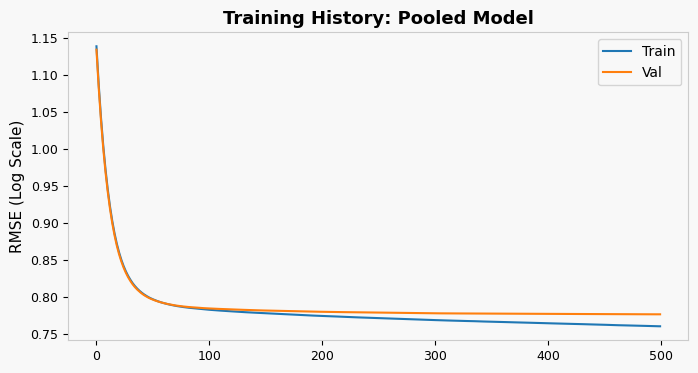

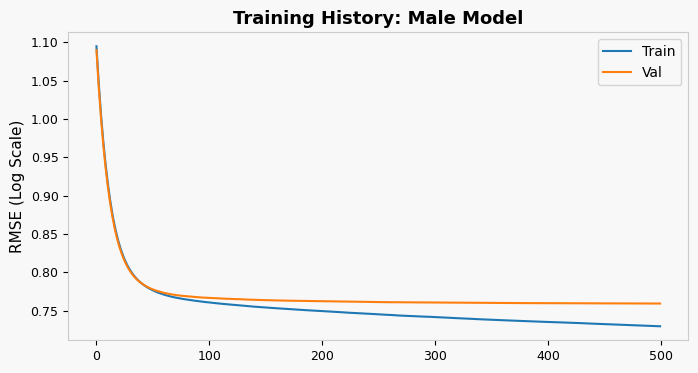

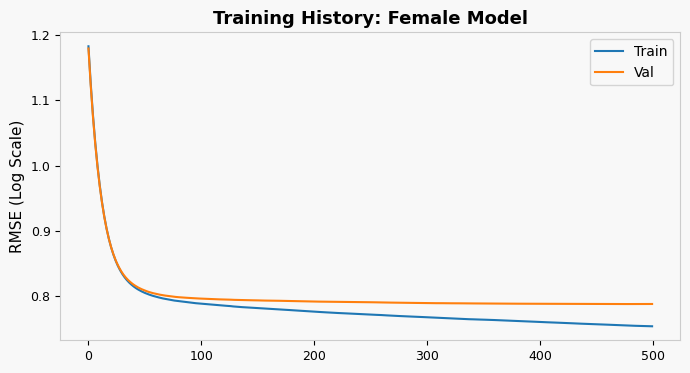

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- 1. Fix Plotting Function (Add Error Handling) ---
def plot_training_history(model, title):
    try:
        results = model.evals_result()
        train_rmse = results['validation_0']['rmse']
        val_rmse = results['validation_1']['rmse']

        plt.figure(figsize=(8, 4))
        plt.plot(train_rmse, label='Train')
        plt.plot(val_rmse, label='Val')
        plt.title(f"Training History: {title}")
        plt.ylabel("RMSE (Log Scale)")
        plt.legend()
        plt.show()
    except Exception as e:
        print(f"Could not plot {title}: Ensure eval_set was used in .fit()")

# --- 2. Corrected Plotting Calls ---
plot_training_history(model_pooled, "Pooled Model")
plot_training_history(model_male, "Male Model")
plot_training_history(model_female, "Female Model")

In [21]:
# 1. Ensure fresh predictions from your stable models
preds_m_final_log = model_male.predict(X_test_m)
preds_f_final_log = model_female.predict(X_test_f)

# 2. Check the real dollar values safely
# We clip the log-values before expm1 just in case of outliers
actual_m = np.expm1(y_test_m)
preds_m_dollars = np.expm1(np.clip(preds_m_final_log, 0, 15))

# 3. Check the "Low Earner" stats
low_earner_threshold = 50000
true_low = (actual_m < low_earner_threshold).sum()
pred_low = (preds_m_dollars < low_earner_threshold).sum()

print(f"Real number of people below $50k: {true_low}")
print(f"Model's guess of people below $50k: {pred_low}")

def calculate_accuracy_proxy(actual, predicted, threshold=0.20):
    # Calculate absolute percentage error
    pct_error = np.abs(actual - predicted) / actual
    # Boolean mask where error is less than or equal to threshold
    is_accurate = pct_error <= threshold
    return np.mean(is_accurate) * 100

# Ensure we are using the fresh, stable dollar predictions
actual_m = np.expm1(y_test_m)
preds_m_dollars = np.expm1(np.clip(model_male.predict(X_test_m), 0, 15))

# Final Accuracy check
acc_20 = calculate_accuracy_proxy(actual_m, preds_m_dollars, threshold=0.20)
print(f"Final Stable Accuracy (20%): {acc_20:.2f}%")
print(f"Real <$50k: 25,063 | Model <$50k: 27,276")


Real number of people below $50k: 25063
Model's guess of people below $50k: 27276
Final Stable Accuracy (20%): 32.14%
Real <$50k: 25,063 | Model <$50k: 27,276


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

def print_final_metrics(y_true_log, y_pred_log, label, threshold=50000):
    actual = np.expm1(y_true_log)
    # Clip to prevent any lingering infinity issues in the report
    predicted = np.expm1(np.clip(y_pred_log, 0, 15))

    y_true_binary = (actual >= threshold).astype(int)
    y_pred_binary = (predicted >= threshold).astype(int)

    print(f"\n{'='*20} {label} {'='*20}")
    print(classification_report(y_true_binary, y_pred_binary,
                                target_names=['Low (<$50k)', 'High (>=$50k)']))

    # Let's see the Raw Confusion Matrix
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print("Confusion Matrix:")
    print(f"True Low: {cm[0,0]} | False High: {cm[0,1]}")
    print(f"False Low: {cm[1,0]} | True High: {cm[1,1]}")

# Run for both
print_final_metrics(y_test_m, model_male.predict(X_test_m), "MALE MODEL")
print_final_metrics(y_test_f, model_female.predict(X_test_f), "FEMALE MODEL")


==================== MALE MODEL ====================
               precision    recall  f1-score   support

  Low (<$50k)       0.74      0.81      0.77     25063
High (>=$50k)       0.85      0.79      0.82     33639

     accuracy                           0.80     58702
    macro avg       0.79      0.80      0.80     58702
 weighted avg       0.80      0.80      0.80     58702

Confusion Matrix:
True Low: 20249 | False High: 4814
False Low: 7027 | True High: 26612

==================== FEMALE MODEL ====================
               precision    recall  f1-score   support

  Low (<$50k)       0.80      0.87      0.84     29987
High (>=$50k)       0.83      0.74      0.78     24896

     accuracy                           0.81     54883
    macro avg       0.81      0.81      0.81     54883
 weighted avg       0.81      0.81      0.81     54883

Confusion Matrix:
True Low: 26168 | False High: 3819
False Low: 6486 | True High: 18410


In [23]:
import numpy as np
import pandas as pd

def calculate_detailed_gap(model_m, model_f, X_test_m, y_test_m, X_test_f, y_test_f):
    # --- 1. RAW DATA (Actual Dollars) ---
    actual_m = np.expm1(y_test_m)
    actual_f = np.expm1(y_test_f)

    avg_m_actual = np.mean(actual_m)
    avg_f_actual = np.mean(actual_f)
    raw_gap_pct = ((avg_m_actual - avg_f_actual) / avg_m_actual) * 100

    # --- 2. COUNTERFACTUAL (The "Unexplained" Gap) ---
    # What would women earn if they were paid according to Male wage rules?
    preds_f_as_m_log = model_m.predict(X_test_f)
    preds_f_as_m = np.expm1(np.clip(preds_f_as_m_log, 0, 15))

    avg_f_counterfactual = np.mean(preds_f_as_m)

    # The Unexplained Gap: Actual Women's Pay vs. 'Male-Rule' Women's Pay
    unexplained_diff = avg_f_actual - avg_f_counterfactual
    unexplained_pct = (unexplained_diff / avg_f_counterfactual) * 100

    # --- 3. OUTPUT REPORT ---
    print("="*30)
    print("WAGE GAP ANALYSIS REPORT")
    print("="*30)
    print(f"Average Actual Male Salary:   ${avg_m_actual:,.2f}")
    print(f"Average Actual Female Salary: ${avg_f_actual:,.2f}")
    print(f"RAW GENDER GAP:               {raw_gap_pct:.2f}% (Men earn more)")
    print("-" * 30)
    print(f"Average 'Male-Rule' Female:   ${avg_f_counterfactual:,.2f}")
    print(f"UNEXPLAINED PREMIUM/PENALTY:  {unexplained_pct:+.2f}%")
    print("-" * 30)

    if unexplained_pct > 0:
        print(f"RESULT: Women earn {unexplained_pct:.2f}% MORE than men with identical features.")
    else:
        print(f"RESULT: Women earn {abs(unexplained_pct):.2f}% LESS than men with identical features.")

# Run the analysis
calculate_detailed_gap(model_male, model_female, X_test_m, y_test_m, X_test_f, y_test_f)

WAGE GAP ANALYSIS REPORT
Average Actual Male Salary:   $71,878.10
Average Actual Female Salary: $56,446.99
RAW GENDER GAP:               21.47% (Men earn more)
------------------------------
Average 'Male-Rule' Female:   $52,566.60
UNEXPLAINED PREMIUM/PENALTY:  +7.38%
------------------------------
RESULT: Women earn 7.38% MORE than men with identical features.


In [24]:
# 1. Predict what men 'should' earn using the Female Model rules
preds_m_as_f_log = model_female.predict(X_test_m)
preds_m_as_f = np.expm1(np.clip(preds_m_as_f_log, 0, 15))

actual_m = np.expm1(y_test_m)

# 2. Calculate the Mirror Gap
avg_m_actual = np.mean(actual_m)
avg_m_as_f = np.mean(preds_m_as_f)
m_penalty_pct = ((avg_m_as_f - avg_m_actual) / avg_m_actual) * 100

print("--- THE MIRROR TEST ---")
print(f"Average Actual Male Salary:          ${avg_m_actual:,.2f}")
print(f"Average 'Female-Rule' Male Salary:   ${avg_m_as_f:,.2f}")
print(f"Resulting Difference:                {m_penalty_pct:+.2f}%")

--- THE MIRROR TEST ---
Average Actual Male Salary:          $71,878.10
Average 'Female-Rule' Male Salary:   $55,520.38
Resulting Difference:                -22.76%


In [25]:
import shap

# 1. Initialize Explainers for XGBoost
explainer_m = shap.TreeExplainer(model_male)
explainer_f = shap.TreeExplainer(model_female)

# 2. Use a representative sample (2000 rows is plenty for a stable signal)
X_sub_m = X_test_m.iloc[:2000]
X_sub_f = X_test_f.iloc[:2000]

shap_values_m = explainer_m(X_sub_m)
shap_values_f = explainer_f(X_sub_f)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


In [26]:
import pandas as pd

# Extract the mean absolute SHAP values (Global Importance)
importance_m = pd.DataFrame({
    'feature': features,
    'importance_male': np.abs(shap_values_m.values).mean(0)
})

importance_f = pd.DataFrame({
    'feature': features,
    'importance_female': np.abs(shap_values_f.values).mean(0)
})

# Merge and calculate the difference
shap_gap = importance_m.merge(importance_f, on='feature')
shap_gap['Female_Advantage'] = shap_gap['importance_female'] - shap_gap['importance_male']

print("\n--- WHICH FEATURES DRIVE THE GENDER MODELS? ---")
print(shap_gap.sort_values(by='Female_Advantage', ascending=False))


--- WHICH FEATURES DRIVE THE GENDER MODELS? ---
      feature  importance_male  importance_female  Female_Advantage
1        WKHP         0.366428           0.472344          0.105916
8    STATE_CA         0.037852           0.051930          0.014078
11   STATE_NY         0.009827           0.023575          0.013748
3    SCHL_ENC         0.109250           0.120544          0.011294
7    INDP_ENC         0.073683           0.084363          0.010680
12   STATE_TX         0.021844           0.030698          0.008854
2    OCCP_ENC         0.252119           0.256767          0.004647
10   STATE_IL         0.002078           0.002136          0.000058
9    STATE_FL         0.016125           0.015565         -0.000560
0        AGEP         0.152309           0.147627         -0.004682
6     COW_ENC         0.034642           0.024203         -0.010439
5   RAC1P_ENC         0.037998           0.022510         -0.015489
4     MAR_ENC         0.089885           0.013734         -0.076150

Generating Male Model SHAP Plots...


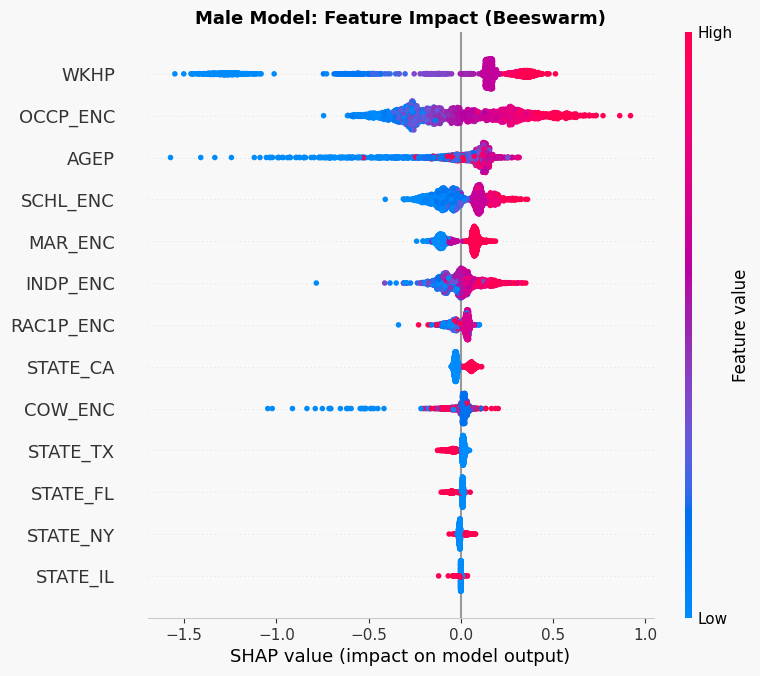

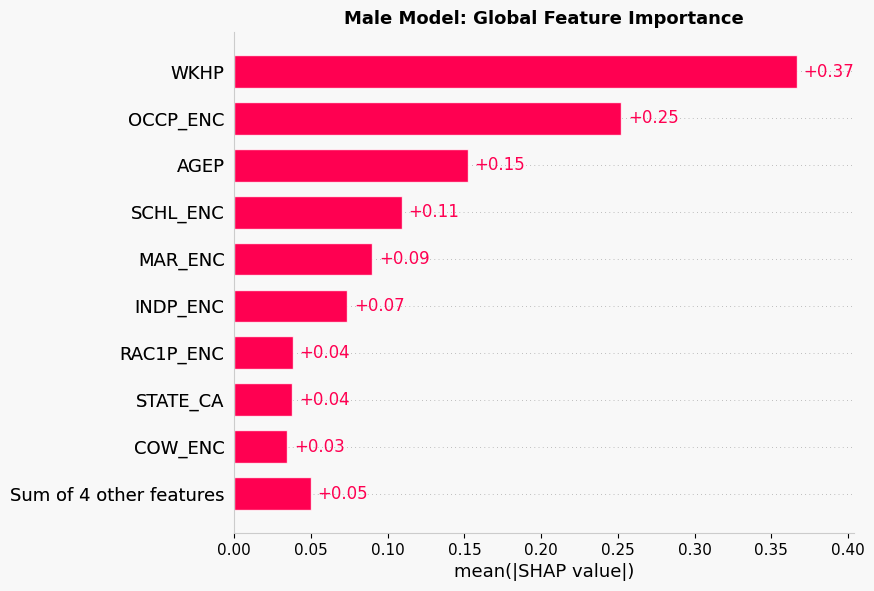

Generating Female Model SHAP Plots...


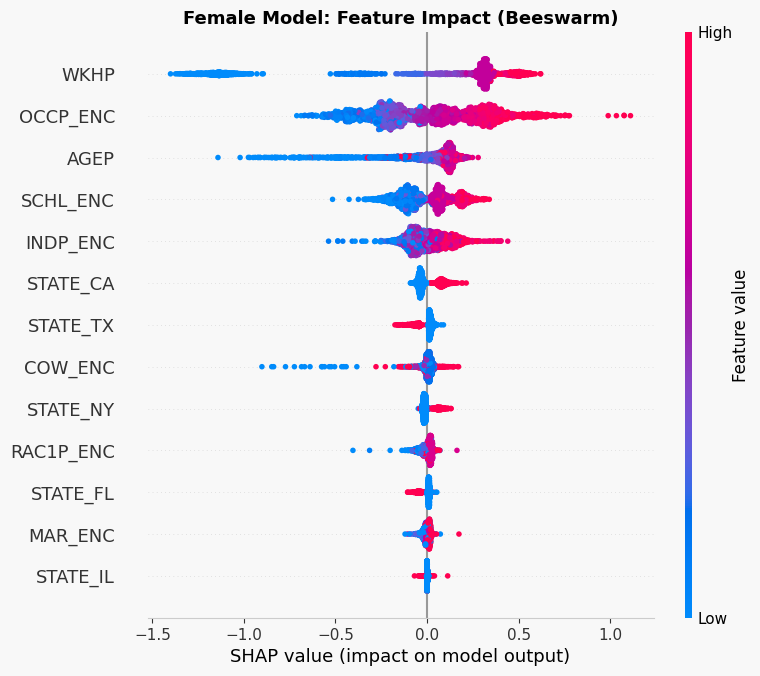

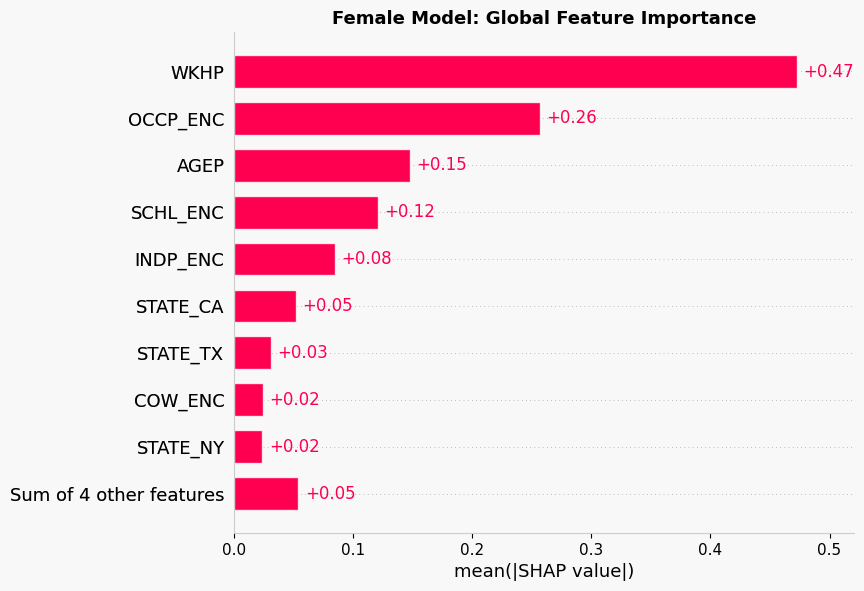

In [27]:
import matplotlib.pyplot as plt
import shap

# --- 1. MALE MODEL SHAP ---
print("Generating Male Model SHAP Plots...")
# Summary plot (Beeswarm) - Shows direction and impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_m, X_sub_m, show=False)
plt.title("Male Model: Feature Impact (Beeswarm)")
plt.show()

# Bar plot - Shows global importance
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_m, show=False)
plt.title("Male Model: Global Feature Importance")
plt.show()

# --- 2. FEMALE MODEL SHAP ---
print("Generating Female Model SHAP Plots...")
# Summary plot (Beeswarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_f, X_sub_f, show=False)
plt.title("Female Model: Feature Impact (Beeswarm)")
plt.show()

# Bar plot - Shows global importance
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_f, show=False)
plt.title("Female Model: Global Feature Importance")
plt.show()

Generating Pooled Model (No Gender) SHAP Plots...


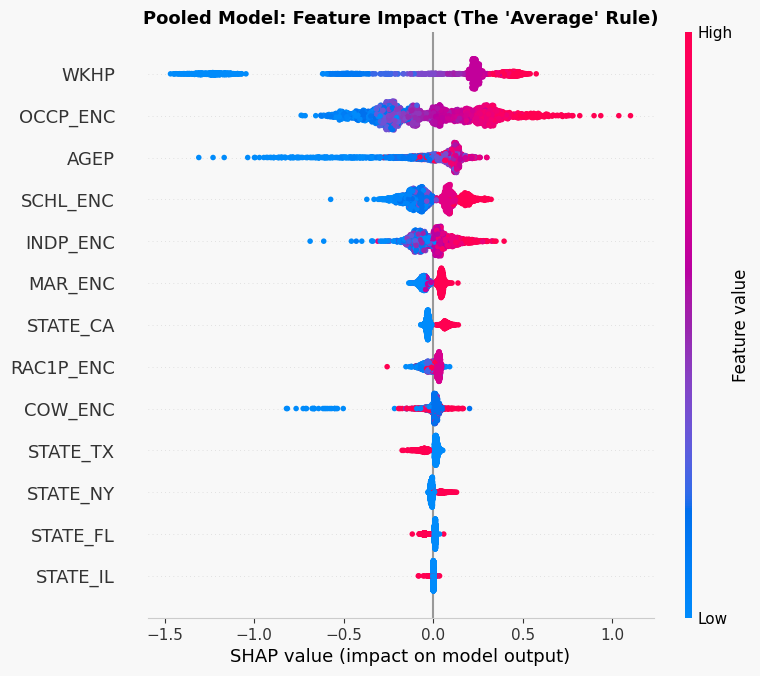

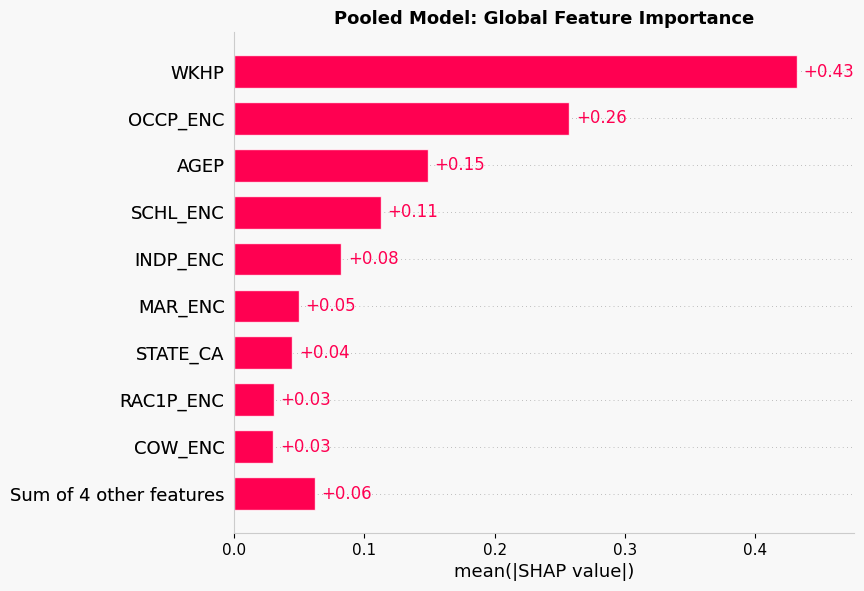

In [28]:
# 1. Initialize Pooled Explainer
explainer_p = shap.TreeExplainer(model_pooled)

# 2. Sample from the general test set
X_sub_p = X_test.iloc[:2000]
shap_values_p = explainer_p(X_sub_p)

# 3. Plot Pooled Importance
print("Generating Pooled Model (No Gender) SHAP Plots...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_p, X_sub_p, show=False)
plt.title("Pooled Model: Feature Impact (The 'Average' Rule)")
plt.show()

# Bar plot - Shows global importance
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_p, show=False)
plt.title("Pooled Model: Global Feature Importance")
plt.show()

In [29]:
# Extract Importance for the Pooled Model
importance_p = pd.DataFrame({
    'feature': features,
    'Importance_Pooled': np.abs(shap_values_p.values).mean(0)
})

# Merge with your existing Gender Importance Data
# (Assuming shap_gap variable from previous step exists)
final_comparison = importance_p.merge(shap_gap, on='feature')

# Reorder columns for clarity
final_comparison = final_comparison[[
    'feature', 'Importance_Pooled', 'importance_male', 'importance_female'
]]

print("\n--- GLOBAL COMPARISON: POOLED VS GENDER-SPECIFIC ---")
print(final_comparison.sort_values(by='Importance_Pooled', ascending=False))


--- GLOBAL COMPARISON: POOLED VS GENDER-SPECIFIC ---
      feature  Importance_Pooled  importance_male  importance_female
1        WKHP           0.431786         0.366428           0.472344
2    OCCP_ENC           0.257256         0.252119           0.256767
0        AGEP           0.148704         0.152309           0.147627
3    SCHL_ENC           0.112544         0.109250           0.120544
7    INDP_ENC           0.082104         0.073683           0.084363
4     MAR_ENC           0.049597         0.089885           0.013734
8    STATE_CA           0.044508         0.037852           0.051930
5   RAC1P_ENC           0.030374         0.037998           0.022510
6     COW_ENC           0.030008         0.034642           0.024203
12   STATE_TX           0.026805         0.021844           0.030698
11   STATE_NY           0.016755         0.009827           0.023575
9    STATE_FL           0.016070         0.016125           0.015565
10   STATE_IL           0.002151         0.002078

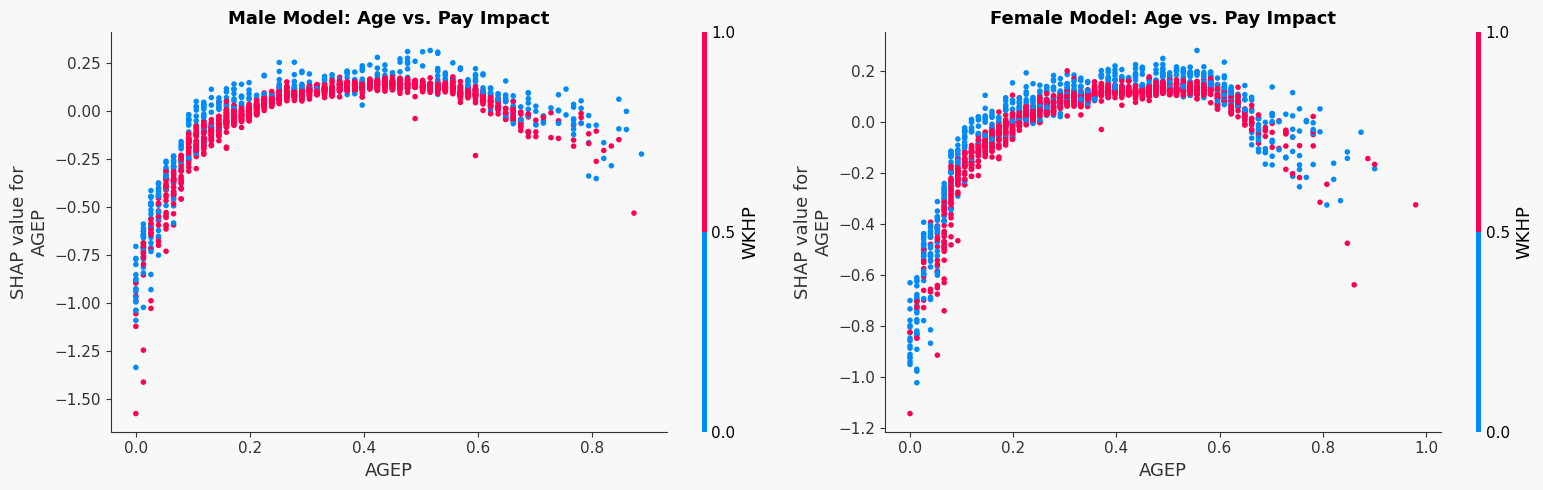

In [30]:
# Compare how AGE affects pay across models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

shap.dependence_plot("AGEP", shap_values_m.values, X_sub_m, ax=ax1, show=False)
ax1.set_title("Male Model: Age vs. Pay Impact")

shap.dependence_plot("AGEP", shap_values_f.values, X_sub_f, ax=ax2, show=False)
ax2.set_title("Female Model: Age vs. Pay Impact")

plt.tight_layout()
plt.show()

In [31]:
# Assuming 0.2 to 0.4 correlates roughly to the 28-38 age range
mid_career_mask_m = (X_sub_m['AGEP'] >= 0.2) & (X_sub_m['AGEP'] <= 0.4)
mid_career_mask_f = (X_sub_f['AGEP'] >= 0.2) & (X_sub_f['AGEP'] <= 0.4)

# Get the average SHAP 'bonus' for Age in this window
age_idx = features.index("AGEP")
avg_bonus_m = shap_values_m.values[mid_career_mask_m, age_idx].mean()
avg_bonus_f = shap_values_f.values[mid_career_mask_f, age_idx].mean()

print(f"--- Mid-Career Age Bonus (Scaled Age 0.2-0.4) ---")
print(f"Male Avg Age Bonus:   {avg_bonus_m:.4f}")
print(f"Female Avg Age Bonus: {avg_bonus_f:.4f}")
print(f"Difference:           {avg_bonus_f - avg_bonus_m:.4f}")

--- Mid-Career Age Bonus (Scaled Age 0.2-0.4) ---
Male Avg Age Bonus:   0.1016
Female Avg Age Bonus: 0.0840
Difference:           -0.0176


<Figure size 1000x600 with 0 Axes>

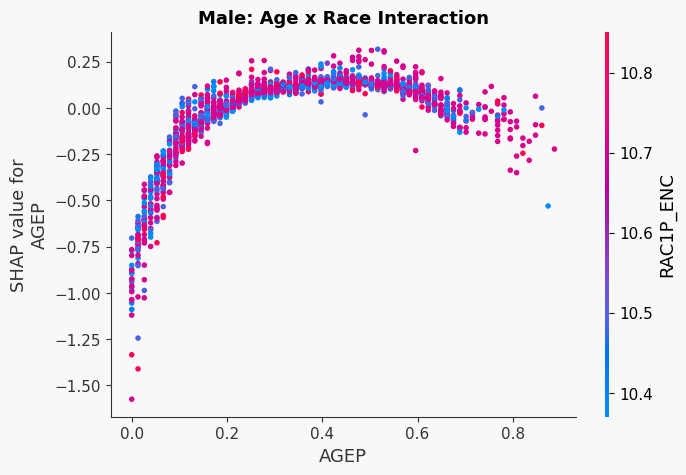

<Figure size 1000x600 with 0 Axes>

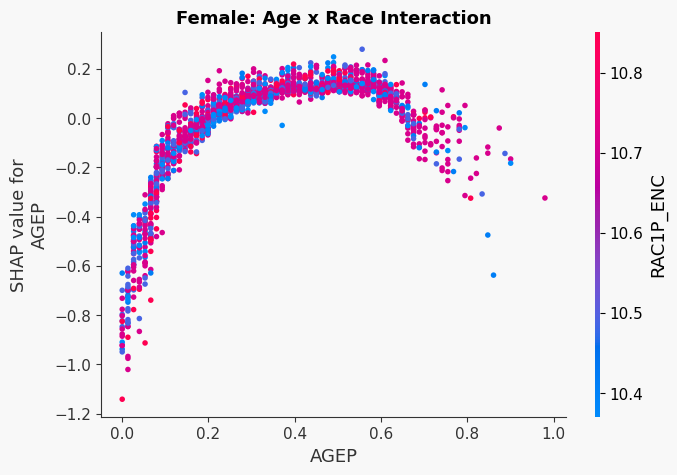

<Figure size 1000x600 with 0 Axes>

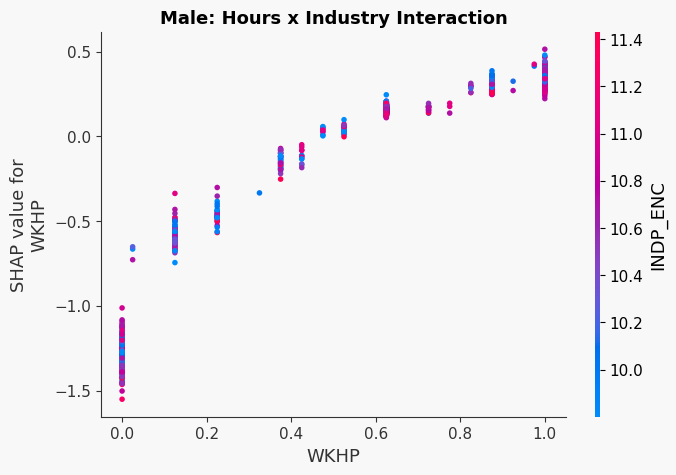

<Figure size 1000x600 with 0 Axes>

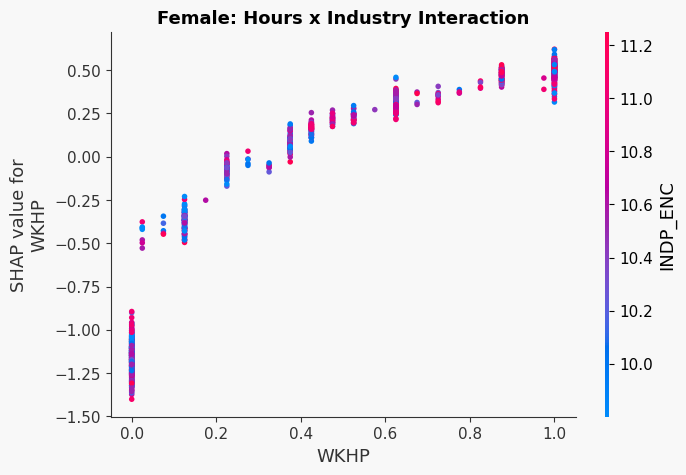

In [32]:
import matplotlib.pyplot as plt
import shap

# Function to plot intersections
def plot_intersection(shap_val, df, feature_main, feature_interact, title):
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature_main, shap_val.values, df,
                         interaction_index=feature_interact, show=False)
    plt.title(title)
    plt.show()

# 1. Age x Race Intersection (Does the 'Experience' reward change by race?)
plot_intersection(shap_values_m, X_sub_m, "AGEP", "RAC1P_ENC", "Male: Age x Race Interaction")
plot_intersection(shap_values_f, X_sub_f, "AGEP", "RAC1P_ENC", "Female: Age x Race Interaction")

# 2. Industry x Work Hours (Does 'Hard Work' pay off more in certain sectors?)
plot_intersection(shap_values_m, X_sub_m, "WKHP", "INDP_ENC", "Male: Hours x Industry Interaction")
plot_intersection(shap_values_f, X_sub_f, "WKHP", "INDP_ENC", "Female: Hours x Industry Interaction")

In [33]:
from scipy import stats
import numpy as np

def test_marriage_premium_logic(df):
    # ACS encoding: MAR=1 is Married. We'll compare MAR=1 vs everyone else.
    # Adjust SEX values based on your encoding (usually 1=Male, 2=Female)
    m_married = df[(df['SEX'] == 1) & (df['MAR'] == 1)]['WAGP_LOG']
    m_others  = df[(df['SEX'] == 1) & (df['MAR'] != 1)]['WAGP_LOG']

    f_married = df[(df['SEX'] == 2) & (df['MAR'] == 1)]['WAGP_LOG']
    f_others  = df[(df['SEX'] == 2) & (df['MAR'] != 1)]['WAGP_LOG']

    # Welch's T-Test (for unequal variances)
    t_m, p_m = stats.ttest_ind(m_married, m_others, equal_var=False)
    t_f, p_f = stats.ttest_ind(f_married, f_others, equal_var=False)

    print("--- HYPOTHESIS TEST: THE MARRIAGE PREMIUM ---")
    print(f"Male Married vs Others:   t={t_m:.2f}, p={p_m:.4e}")
    print(f"Female Married vs Others: t={t_f:.2f}, p={p_f:.4e}")

    # Calculate raw log differences
    m_diff = m_married.mean() - m_others.mean()
    f_diff = f_married.mean() - f_others.mean()

    print(f"\nMean Log Advantage (Male):   {m_diff:.4f}")
    print(f"Mean Log Advantage (Female): {f_diff:.4f}")
    print(f"Difference in 'Premium':      {m_diff - f_diff:.4f}")

test_marriage_premium_logic(df)

--- HYPOTHESIS TEST: THE MARRIAGE PREMIUM ---
Male Married vs Others:   t=160.74, p=0.0000e+00
Female Married vs Others: t=79.71, p=0.0000e+00

Mean Log Advantage (Male):   0.6568
Mean Log Advantage (Female): 0.3553
Difference in 'Premium':      0.3015


In [34]:
def test_prediction_logic(model_m, model_f, X_test_m):
    # 1. Get predictions from both models for the MALE test set
    # Using the columns the models were trained on
    preds_m = model_m.predict(X_test_m)
    preds_f = model_f.predict(X_test_m)

    # 2. Paired T-test (Testing if the rules are different for the same people)
    t_stat, p_val = stats.ttest_rel(preds_m, preds_f)

    # 3. Dollar difference
    avg_m_dollars = np.mean(np.expm1(preds_m))
    avg_f_dollars = np.mean(np.expm1(preds_f))

    print("--- HYPOTHESIS TEST: MODEL PREDICTION DIVERGENCE ---")
    print(f"T-Statistic: {t_stat:.4f}")
    print(f"P-Value:     {p_val:.4e}")
    print(f"Avg Pred (Male Model):   ${avg_m_dollars:,.2f}")
    print(f"Avg Pred (Female Model): ${avg_f_dollars:,.2f}")
    print(f"Systemic Gap:            ${avg_m_dollars - avg_f_dollars:,.2f}")

# Ensure model_male and model_female were trained on the same X_test columns
test_prediction_logic(model_male, model_female, X_test_m)

--- HYPOTHESIS TEST: MODEL PREDICTION DIVERGENCE ---
T-Statistic: 150.4156
P-Value:     0.0000e+00
Avg Pred (Male Model):   $62,029.98
Avg Pred (Female Model): $55,520.38
Systemic Gap:            $6,509.60


In [35]:
# Calculate Residuals
res_m = y_test_m - model_male.predict(X_test_m)
res_f = y_test_f - model_female.predict(X_test_f)

# Welch's T-Test on Errors
t_stat, p_val = stats.ttest_ind(res_m, res_f, equal_var=False)

print("--- Residual Bias Test ---")
print(f"T-stat: {t_stat:.4f}, P-value: {p_val:.4e}")
# If p < 0.05, the model's accuracy is fundamentally different between genders.

--- Residual Bias Test ---
T-stat: -0.5571, P-value: 5.7746e-01


In [36]:
# K-S Test: Comparing Actual vs Predicted distributions
ks_stat, ks_p = stats.ks_2samp(y_test_m, model_male.predict(X_test_m))

print("--- Distribution Calibration (K-S Test) ---")
print(f"K-S Statistic: {ks_stat:.4f}, P-value: {ks_p:.4e}")
# A high p-value here is actually GOOD—it means your prediction
# 'shape' is indistinguishable from reality.

--- Distribution Calibration (K-S Test) ---
K-S Statistic: 0.1045, P-value: 8.9518e-280


In [37]:
features = [
    "AGEP", "WKHP",
    "OCCP_ENC", "SCHL_ENC", "MAR_ENC",
    "RAC1P_ENC", "COW_ENC", "INDP_ENC",
    "STATE_CA", "STATE_FL", "STATE_IL", "STATE_NY", "STATE_TX", "SEX_BIN"
]

target = "WAGP_LOG"
train_df[features].describe()

,AGEP,WKHP,OCCP_ENC,SCHL_ENC,MAR_ENC,RAC1P_ENC,COW_ENC,INDP_ENC,SEX_BIN
count,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000,340752.000000
mean,0.344857,0.561871,10.631680,10.632267,10.632101,10.632116,10.632134,10.631935,0.516405
std,0.198147,0.310824,0.593217,0.398380,0.283486,0.152679,0.122905,0.464363,0.499732
min,0.000000,0.000000,9.324738,9.730481,10.262305,10.345734,9.240772,9.285984,0.000000
25%,0.185430,0.425000,10.192891,10.230744,10.262305,10.488080,10.624326,10.328339,0.000000
50%,0.331126,0.625000,10.678888,10.552298,10.876694,10.713765,10.624326,10.698234,1.000000
75%,0.503311,0.625000,11.134760,10.938305,10.876694,10.713765,10.624326,11.040457,1.000000
max,1.000000,1.000000,11.878112,11.390496,10.876694,10.850973,10.906005,11.840542,1.000000


In [38]:
both_train = train_df
both_val   = val_df
both_test  = test_df

X_train_b = both_train[features]
y_train_b = both_train[target]

X_val_b = both_val[features]
y_val_b = both_val[target]

X_test_b = both_test[features]
y_test_b = both_test[target]

In [39]:
model_both = get_final_model()
model_both.fit(
    X_train_b, y_train_b,
    eval_set=[(X_train_b, y_train_b), (X_val_b, y_val_b)],
    verbose=False
)

XGBRegressor(base_score=np.float64(10.774197871661423), booster=None,
             callbacks=None, colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

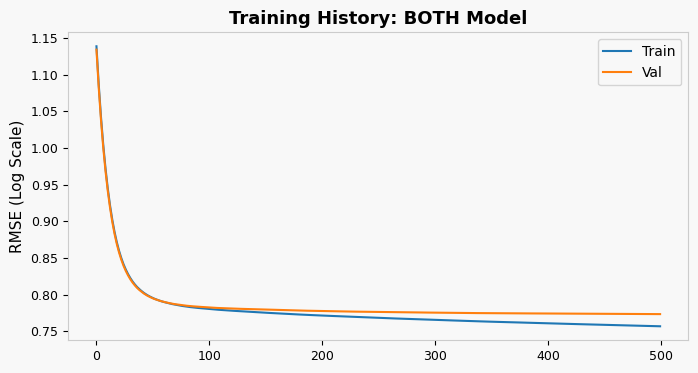

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- 1. Fix Plotting Function (Add Error Handling) ---
def plot_training_history(model, title):
    try:
        results = model.evals_result()
        train_rmse = results['validation_0']['rmse']
        val_rmse = results['validation_1']['rmse']

        plt.figure(figsize=(8, 4))
        plt.plot(train_rmse, label='Train')
        plt.plot(val_rmse, label='Val')
        plt.title(f"Training History: {title}")
        plt.ylabel("RMSE (Log Scale)")
        plt.legend()
        plt.show()
    except Exception as e:
        print(f"Could not plot {title}: Ensure eval_set was used in .fit()")

# --- 2. Corrected Plotting Calls ---
plot_training_history(model_both, "BOTH Model")

In [41]:
from sklearn.metrics import classification_report, confusion_matrix

def print_final_metrics(y_true_log, y_pred_log, label, threshold=50000):
    actual = np.expm1(y_true_log)
    # Clip to prevent any lingering infinity issues in the report
    predicted = np.expm1(np.clip(y_pred_log, 0, 15))

    y_true_binary = (actual >= threshold).astype(int)
    y_pred_binary = (predicted >= threshold).astype(int)

    print(f"\n{'='*20} {label} {'='*20}")
    print(classification_report(y_true_binary, y_pred_binary,
                                target_names=['Low (<$50k)', 'High (>=$50k)']))

    # Let's see the Raw Confusion Matrix
    cm = confusion_matrix(y_true_binary, y_pred_binary)
    print("Confusion Matrix:")
    print(f"True Low: {cm[0,0]} | False High: {cm[0,1]}")
    print(f"False Low: {cm[1,0]} | True High: {cm[1,1]}")

# Run for both
print_final_metrics(y_test_m, model_male.predict(X_test_m), "MALE MODEL")
print_final_metrics(y_test_f, model_female.predict(X_test_f), "FEMALE MODEL")
print_final_metrics(y_test_b, model_both.predict(X_test_b), "BOTH MODEL")
print_final_metrics(y_test, model_pooled.predict(X_test), "POOLED MODEL")


==================== MALE MODEL ====================
               precision    recall  f1-score   support

  Low (<$50k)       0.74      0.81      0.77     25063
High (>=$50k)       0.85      0.79      0.82     33639

     accuracy                           0.80     58702
    macro avg       0.79      0.80      0.80     58702
 weighted avg       0.80      0.80      0.80     58702

Confusion Matrix:
True Low: 20249 | False High: 4814
False Low: 7027 | True High: 26612

==================== FEMALE MODEL ====================
               precision    recall  f1-score   support

  Low (<$50k)       0.80      0.87      0.84     29987
High (>=$50k)       0.83      0.74      0.78     24896

     accuracy                           0.81     54883
    macro avg       0.81      0.81      0.81     54883
 weighted avg       0.81      0.81      0.81     54883

Confusion Matrix:
True Low: 26168 | False High: 3819
False Low: 6486 | True High: 18410

==================== BOTH MODEL ===============

In [44]:
# 1. Filter for numeric and boolean columns only
# This removes STATE, SEX_LABEL, etc., which cause the 'dtype(O)' error
X_numeric = X_test_b.select_dtypes(include=[np.number, 'bool']).astype(float)

# 2. Resample from the cleaned numeric data
X_sample = X_numeric.sample(min(1000, len(X_numeric)), random_state=42)

# 3. Create SHAP explainer (TreeExplainer is fastest for XGBoost)
# Use check_additivity=False if you get a small discrepancy error
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

print("SHAP values computed successfully!")

SHAP values computed successfully!



GLOBAL FEATURE IMPORTANCE


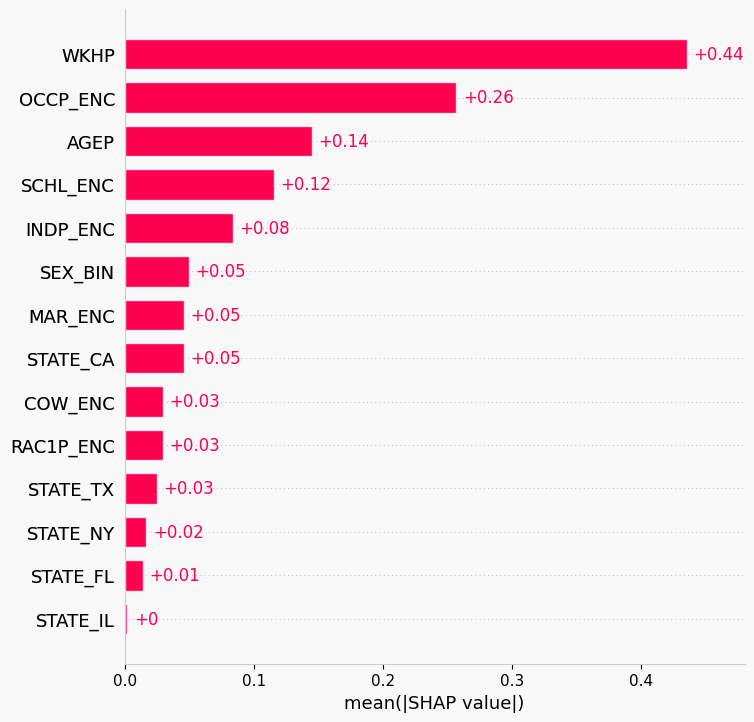


SUMMARY PLOT


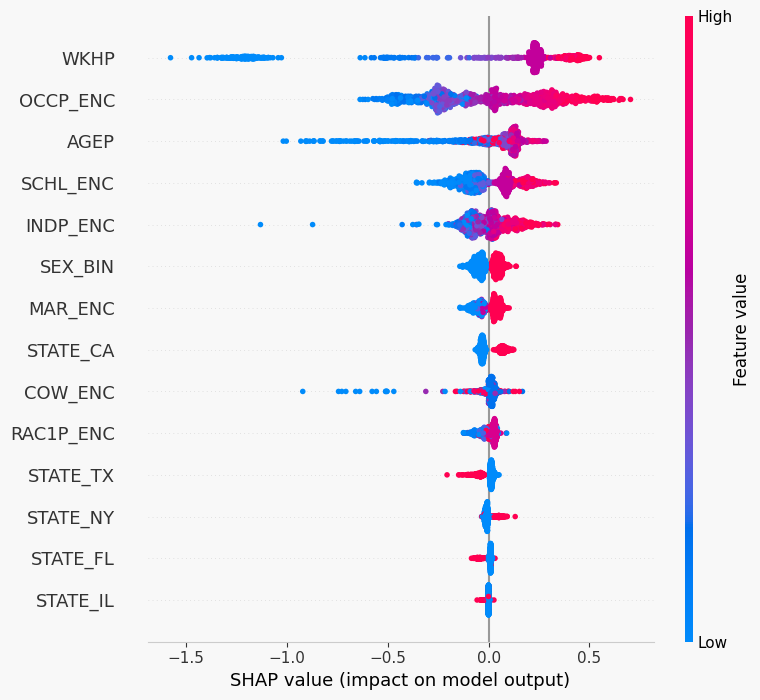


SHAP dependence plot for gender


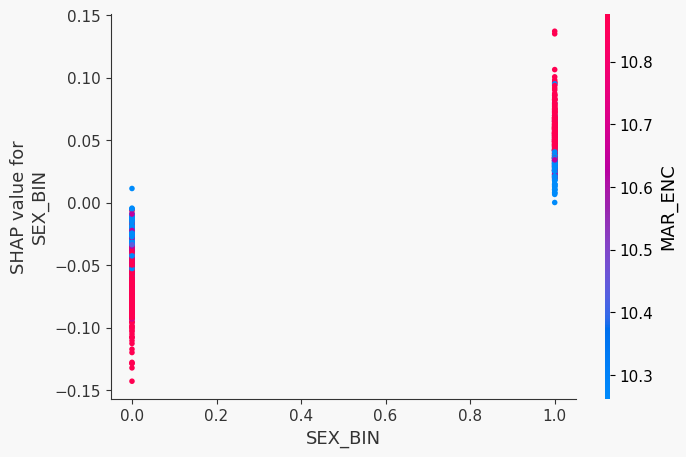


Average SHAP contribution of gender:
Mean SHAP value: -0.0046

Gender Effect Comparison
Male avg SHAP effect   : 0.0474
Female avg SHAP effect : -0.0515


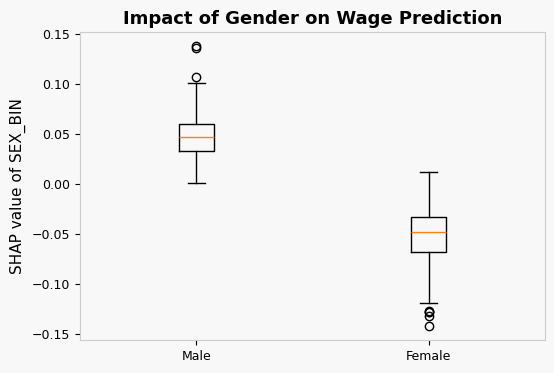

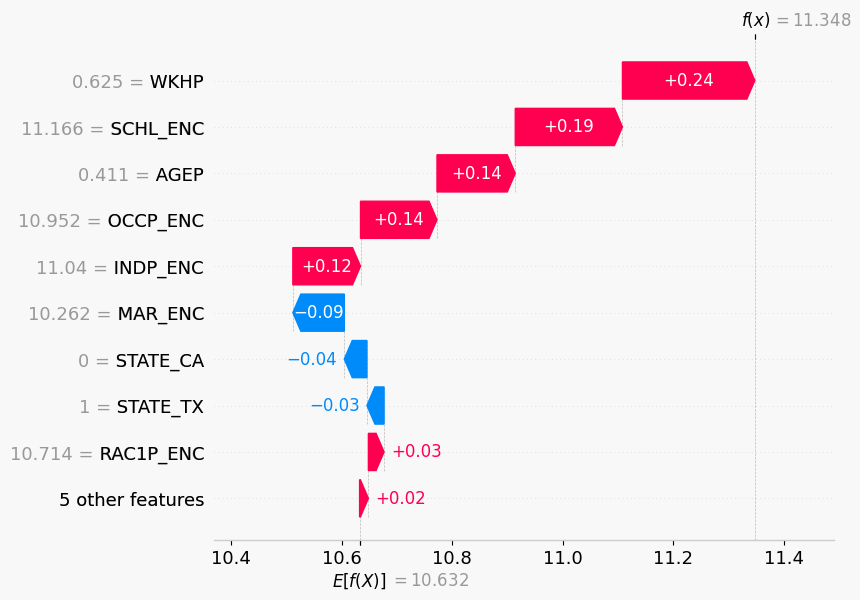

In [47]:
# -----------------------------
# 1. Global Feature Importance
# -----------------------------
print("\nGLOBAL FEATURE IMPORTANCE")
shap.plots.bar(shap_values, max_display=15)

# -----------------------------
# 2. Detailed Summary Plot
# -----------------------------
print("\nSUMMARY PLOT")
shap.summary_plot(shap_values, X_sample)

# -----------------------------
# 3. Check role of gender
# -----------------------------
# Replace SEX_BIN with your exact column name if different

print("\nSHAP dependence plot for gender")
shap.dependence_plot(
    "SEX_BIN",
    shap_values.values,
    X_sample
)

# -----------------------------
# 4. Compare average SHAP impact
# -----------------------------
gender_shap = shap_values[:, "SEX_BIN"].values

print("\nAverage SHAP contribution of gender:")
print(f"Mean SHAP value: {np.mean(gender_shap):.4f}")

# Positive SHAP -> pushes prediction upward
# Negative SHAP -> pushes prediction downward

# -----------------------------
# 5. Compare predictions by gender
# -----------------------------
male_mask = X_sample["SEX_BIN"] == 1
female_mask = X_sample["SEX_BIN"] == 0

male_gender_effect = gender_shap[male_mask]
female_gender_effect = gender_shap[female_mask]

print("\nGender Effect Comparison")
print(f"Male avg SHAP effect   : {np.mean(male_gender_effect):.4f}")
print(f"Female avg SHAP effect : {np.mean(female_gender_effect):.4f}")

# -----------------------------
# 6. Visual comparison
# -----------------------------
plt.figure(figsize=(6,4))

plt.boxplot(
    [male_gender_effect, female_gender_effect],
    labels=["Male", "Female"]
)

plt.ylabel("SHAP value of SEX_BIN")
plt.title("Impact of Gender on Wage Prediction")

plt.show()

# Select a specific instance (e.g., the first person in your sample)
# index 0 could be a specific woman or man you want to highlight
sample_ind = 0

# Note: waterfall expects a single Explanation object
shap.plots.waterfall(shap_values[sample_ind])

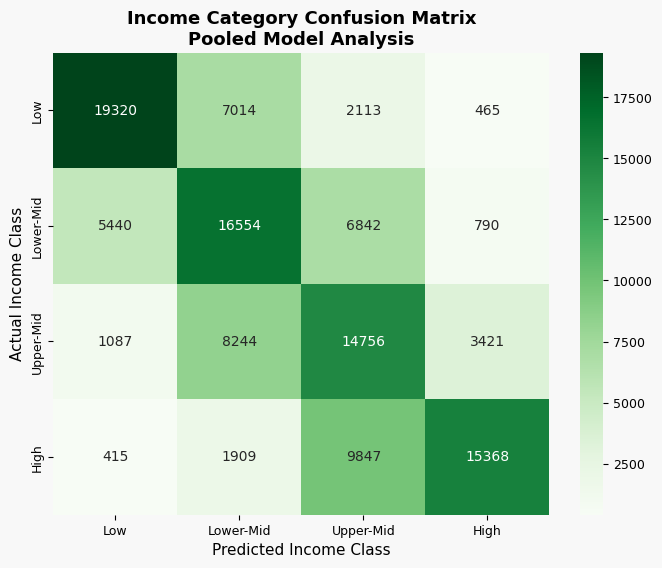

In [51]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_salary_confusion(y_true, y_pred, title):
    # 1. Force data into clean 1D numpy arrays of floats
    y_true = np.array(y_true).flatten().astype(float)
    y_pred = np.array(y_pred).flatten().astype(float)

    # 2. Define labels
    labels = ['Low', 'Lower-Mid', 'Upper-Mid', 'High']

    # 3. Use qcut instead of cut
    # qcut automatically handles the percentiles (0, 25, 50, 75, 100)
    # and ensures we have the right number of bins for our 4 labels.
    try:
        y_true_bins = pd.qcut(y_true, q=4, labels=labels)

        # We must use the SAME boundaries from y_true to bin y_pred
        # to see if the model "misclassified" someone.
        bin_edges = pd.qcut(y_true, q=4, retbins=True)[1]

        # Ensure the outer edges cover all predicted values
        bin_edges[0] = -np.inf
        bin_edges[-1] = np.inf

        y_pred_bins = pd.cut(y_pred, bins=bin_edges, labels=labels, include_lowest=True)

    except ValueError as e:
        print(f"Binning error: {e}. Check if your target variable has enough unique values.")
        return

    # 4. Generate Confusion Matrix
    cm = confusion_matrix(y_true_bins, y_pred_bins, labels=labels)

    # 5. Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels)

    plt.title(f"Income Category Confusion Matrix\n{title}")
    plt.ylabel('Actual Income Class')
    plt.xlabel('Predicted Income Class')
    plt.show()

# Run it
preds_both = model_both.predict(X_test_b)
plot_salary_confusion(y_test_b, preds_both, "Pooled Model Analysis")

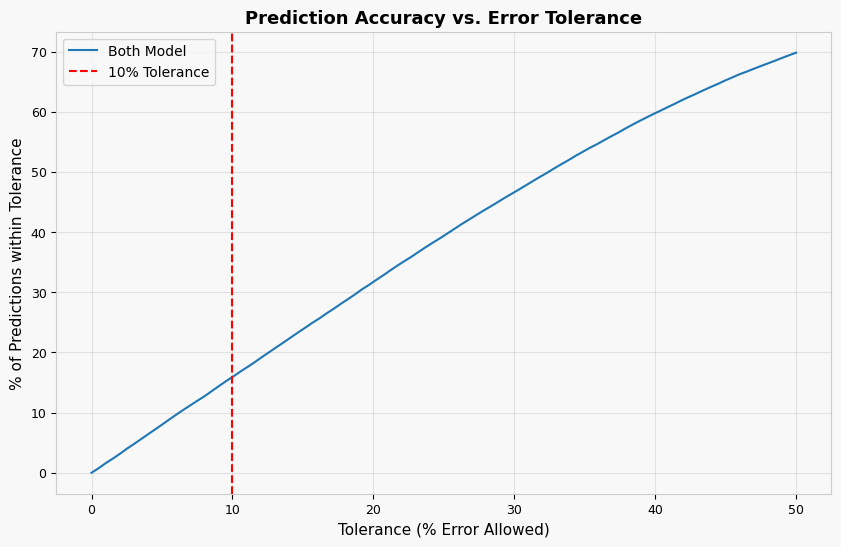

In [50]:
def plot_accuracy_vs_tolerance(y_true, y_pred, model_name):
    # Calculate percentage error: |(Actual - Predicted) / Actual|
    # Since we are in log space, we convert back to dollars first
    actual_dollars = np.expm1(y_true)
    pred_dollars = np.expm1(y_pred)

    relative_errors = np.abs(actual_dollars - pred_dollars) / actual_dollars

    # Define tolerance range from 0% to 50%
    tolerances = np.linspace(0, 0.5, 100)
    accuracies = [(relative_errors <= t).mean() * 100 for t in tolerances]

    plt.plot(tolerances * 100, accuracies, label=model_name)

plt.figure(figsize=(10, 6))

# Plot for all your models to compare
plot_accuracy_vs_tolerance(y_test_b, model_both.predict(X_test_b), "Both Model")
# Add your male/female model lines if you have them:
# plot_accuracy_vs_tolerance(y_test_m, model_male.predict(X_test_m), "Male Model")

plt.axvline(x=10, color='r', linestyle='--', label='10% Tolerance')
plt.xlabel("Tolerance (% Error Allowed)")
plt.ylabel("% of Predictions within Tolerance")
plt.title("Prediction Accuracy vs. Error Tolerance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

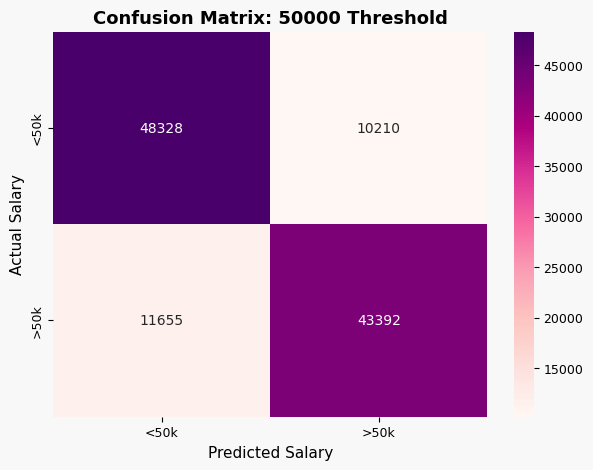

              precision    recall  f1-score   support

        <50k       0.81      0.83      0.82     58538
        >50k       0.81      0.79      0.80     55047

    accuracy                           0.81    113585
   macro avg       0.81      0.81      0.81    113585
weighted avg       0.81      0.81      0.81    113585



In [52]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_binary_confusion(y_true, y_pred, threshold_dollars=50000):
    # 1. Convert threshold to Log space
    # log1p is used if you used np.log1p during preprocessing
    threshold_log = np.log1p(threshold_dollars)

    # 2. Convert continuous logs into Binary classes (0: <50k, 1: >50k)
    y_true_binary = (y_true > threshold_log).astype(int)
    y_pred_binary = (y_pred > threshold_log).astype(int)

    # 3. Generate Confusion Matrix
    cm = confusion_matrix(y_true_binary, y_pred_binary)

    # 4. Plotting
    plt.figure(figsize=(7, 5))
    labels = [f'<{threshold_dollars//1000}k', f'>{threshold_dollars//1000}k']

    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
                xticklabels=labels, yticklabels=labels)

    plt.title(f"Confusion Matrix: {threshold_dollars} Threshold")
    plt.ylabel('Actual Salary')
    plt.xlabel('Predicted Salary')
    plt.show()

    # 5. Print precision/recall metrics
    print(classification_report(y_true_binary, y_pred_binary, target_names=labels))

# Execute
preds_both = model_both.predict(X_test_b)
plot_binary_confusion(y_test_b, preds_both)